# Project Background

This project was developed for a fast-growing machine learning startup focused on delivering **AI-driven decision systems** for the **European banking sector**. The company partners with financial institutions to optimize customer engagement, improve conversion rates, and support data-driven decision-making under **strict regulatory and interpretability requirements**.

In highly competitive retail banking markets, **direct marketing campaigns**, particularly outbound call center operations, remain a key revenue channel. However, these campaigns are:

- Costly  
- Intrusive for customers  
- Often inefficient due to poor targeting  

Improving the success rate of outbound calls is critical for banks to:

- Reduce operational costs  
- Improve customer experience  
- Increase return on marketing investment  

This project focuses on building a **robust, interpretable machine learning system** that predicts whether a customer will subscribe to a **term deposit** after a marketing call. Beyond prediction, the system is designed to help banks understand **which customer segments should be prioritized in future campaigns.** 

# Data Background

The dataset originates from **direct phone marketing campaigns** conducted by a **European banking institution**.

Each row represents a customer who was contacted **at least once** during a campaign promoting a **term deposit product**.

All **personally identifiable information (PII)** has been removed to comply with **privacy and regulatory constraints**.

The dataset contains:

- **40,000 customer records**
- **14 variables** (13 features + 1 target)

The data includes a mix of:

- Demographic attributes  
- Financial indicators  
- Campaign interaction details

# Features 

## Demographic Information

- **age**: Age of the customer (numeric)  
- **job**: Type of occupation (categorical)  
- **marital**: Marital status (categorical)  
- **education**: Education level (categorical)  

## Financial Information

- **default**: Has credit in default? (binary)  
- **balance**: Average yearly account balance in euros (numeric)  
- **housing**: Has a housing loan? (binary)  
- **loan**: Has a personal loan? (binary)  

## Campaign & Contact Information

- **contact**: Communication type used to reach the customer (categorical)  
- **day**: Last contact day of the month (numeric)  
- **month**: Last contact month of the year (categorical)  
- **duration**: Duration of the last call in seconds (numeric)  
- **campaign**: Number of contacts made during the current campaign (numeric)  

## Target Variable

- **y**: Customer subscription outcome  
  - **0** → Customer did not subscribe to the term deposit  
  - **1** → Customer subscribed to the term deposit  


# Goal of the Project

The primary goal of this project is to build a **binary classification model** that predicts whether a customer will **subscribe to a term deposit** following a call center interaction.

Beyond prediction accuracy, the project emphasizes:

- **Customer segmentation**: Identifying which types of customers are most likely to convert  
- **Feature impact analysis**: Understanding what drives customer decisions  
- **Interpretability**: Ensuring model outputs can be explained to business stakeholders and comply with banking regulations  

These insights enable banks to:

- Prioritize high-value customer segments  
- Optimize call timing and strategy  
- Reduce unnecessary customer outreach  
- Improve overall campaign effectiveness  

# Success Metrics

The primary evaluation metric for this project is **classification accuracy**.

Model performance is assessed using **5-fold cross-validation**, with the final score reported as the **average accuracy across folds**.

A model is considered successful if it achieves:

- **81% accuracy or higher**

In addition to accuracy, strong emphasis is placed on:

- **Model stability** across folds  
- **Explainable feature importance**  
- **Actionable business insights**, not just predictive performance  


# Business Impact & Insights

This project helps answer critical business questions such as:

- Which customers should we call first?  
- What customer characteristics indicate a higher likelihood of subscription?  
- Which features most influence purchasing decisions?  

The resulting system supports a shift from **mass outbound calling** to **intelligent, targeted customer engagement**, improving both **customer experience** and **bank profitability**.

# Imporing Necessary Modules and Functions

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, silhouette_score
from itertools import combinations
from scipy.stats import chi2_contingency
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
import category_encoders as ce
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv(r"C:\Users\Prashal\Downloads\term-deposit-marketing-2020.csv")

In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='object')

In [4]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y


The dataset contains no duplicate records, ensuring each row represents a unique customer-campaign interaction.

In [5]:
df.shape

(40000, 14)

In [6]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [7]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no
39999,38,technician,married,secondary,no,1442,yes,no,cellular,3,jun,113,1,no


In [8]:
df.dtypes.value_counts()

object    9
int64     5
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [10]:
(df == 'unknown').sum()

age              0
job            235
marital          0
education     1531
default          0
balance          0
housing          0
loan             0
contact      12765
day              0
month            0
duration         0
campaign         0
y                0
dtype: int64

In [11]:
df[df['job'] == 'unknown'].shape[0]/df.shape[0]

0.005875

In [12]:
df[df['job'] == 'unknown']['y'].value_counts(normalize=True)

y
no     0.92766
yes    0.07234
Name: proportion, dtype: float64

In [13]:
df[df['education'] == 'unknown'].shape[0]/df.shape[0]

0.038275

In [14]:
df[df['education'] == 'unknown']['y'].value_counts(normalize=True)

y
no     0.937296
yes    0.062704
Name: proportion, dtype: float64

In [15]:
df[df['contact'] == 'unknown'].shape[0]/df.shape[0]

0.319125

In [16]:
df[df['contact'] == 'unknown']['y'].value_counts(normalize=True)

y
no     0.961065
yes    0.038935
Name: proportion, dtype: float64

The dataset contains no missing values. However, three categorical features (job, education, contact) include the label unknown, which represents unspecified or unrecorded information rather than true missing data. These will be replaced with the mode of each respective feature to ensure data consistency for modeling.

In [17]:
categorical_cols_with_unknown = ['job', 'education', 'contact']
for col in categorical_cols_with_unknown:
    mode_value = df[col].mode()[0]
    df[col] = df[col].replace('unknown', mode_value)

In [18]:
(df == 'unknown').sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

In [19]:
X = df.drop(columns=['y'])
df['y'] = df['y'].map({'yes': 1, 'no': 0})
y = df['y']

numeric_features = ['age', 'balance', 'day', 'duration', 'campaign']

categorical_features = ['job', 'marital', 'education', 'default', 'housing','loan', 'contact', 'month']

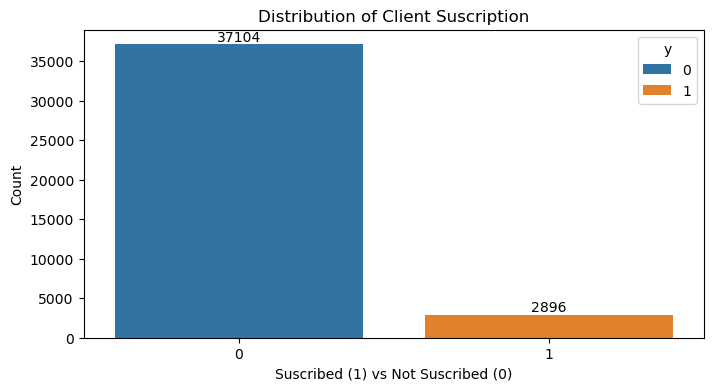

In [20]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x=y, hue=y)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Client Suscription')
plt.xlabel('Suscribed (1) vs Not Suscribed (0)')
plt.ylabel('Count')
plt.show()

In [21]:
y.value_counts(normalize=True)

y
0    0.9276
1    0.0724
Name: proportion, dtype: float64

## Key Takeaway: Severe Class Imbalance

The most critical observation from the target variable distribution is the **extreme class imbalance**.

- **Mean of `y` = 0.0724**
  - This implies that only **~7.2%** of customers subscribed to the term deposit (`y = 1`)
  - Approximately **92.8%** did **not** subscribe (`y = 0`)

### Implications for Modeling

- A naive model that always predicts **"No"** would achieve high accuracy, yet provide **no real business value**
- Standard **accuracy** is therefore a **misleading metric** in this scenario

This imbalance has important consequences for how we evaluate and compare models. To properly assess model performance under class imbalance, we can rely on **ROC–AUC**.

## Categorical Univariate Analysis

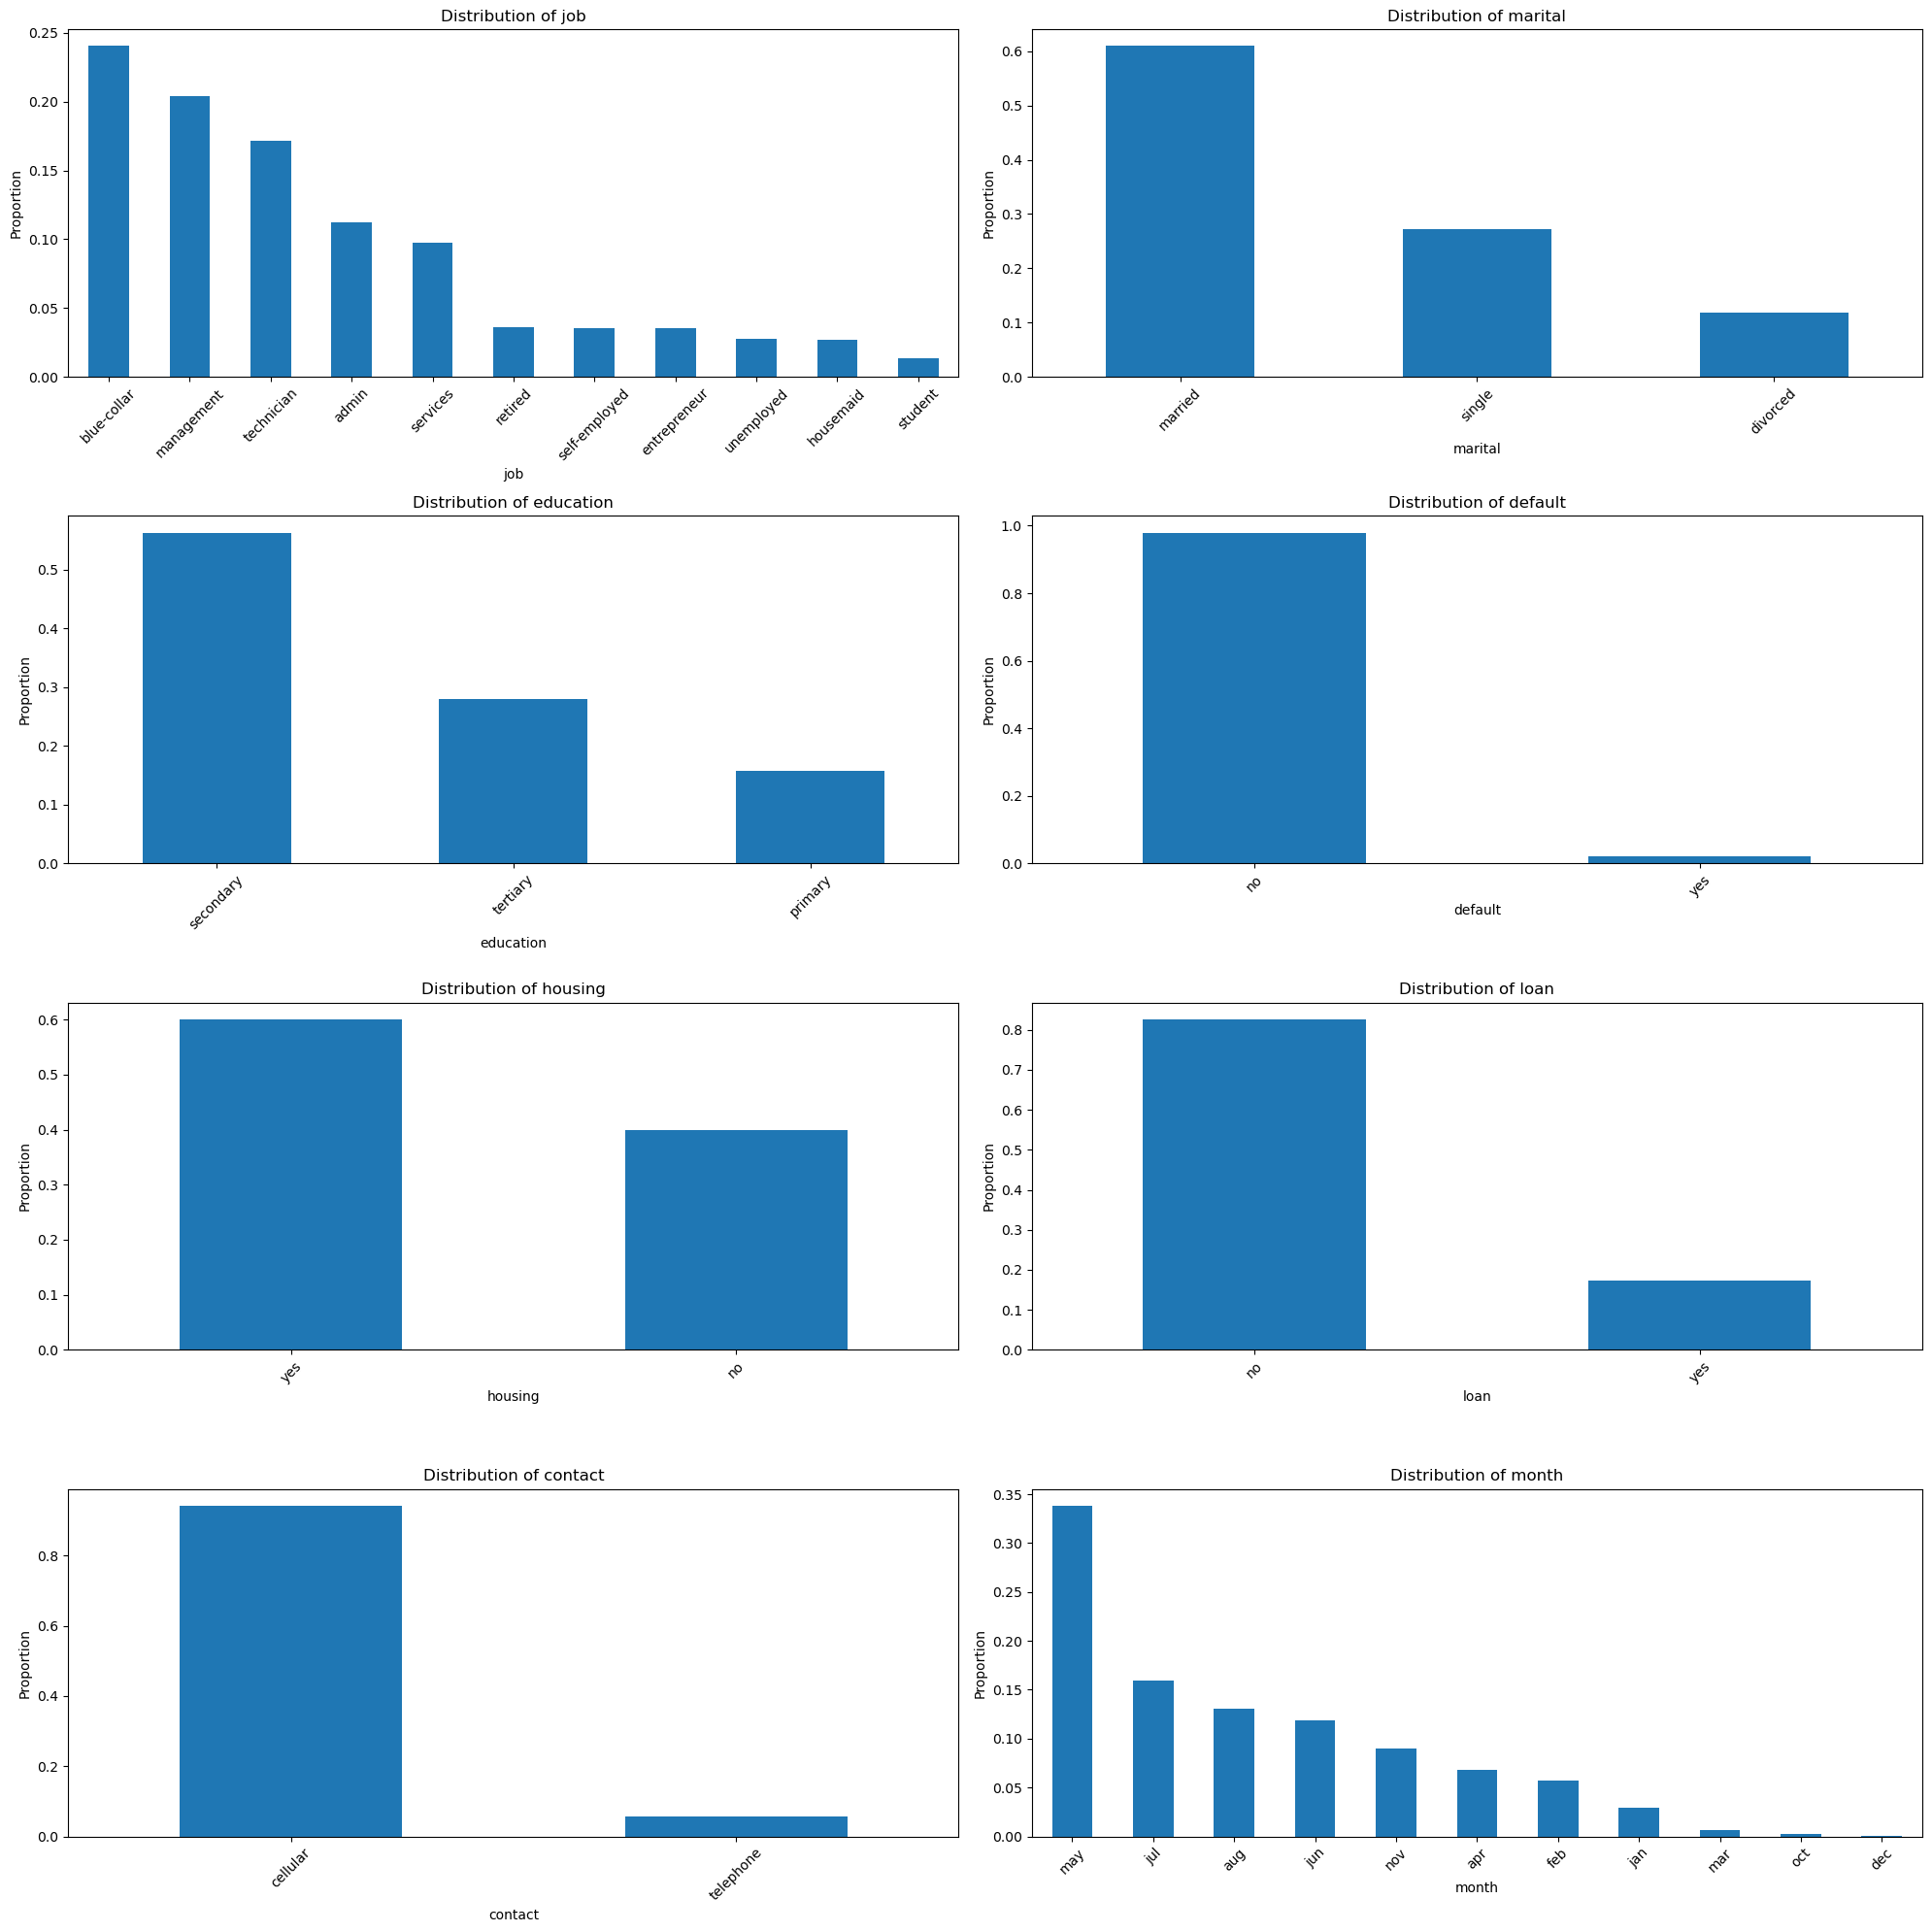

In [22]:
plt.figure(figsize=(20, 20))

for i, col in enumerate(categorical_features, start=1):
    plt.subplot(4, 2, i)
    df[col].value_counts(normalize=True).sort_values(ascending=False).plot(kind='bar', stacked='True')
    plt.title(f'Distribution of {col}')
    plt.ylabel('Proportion')
    plt.xlabel(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

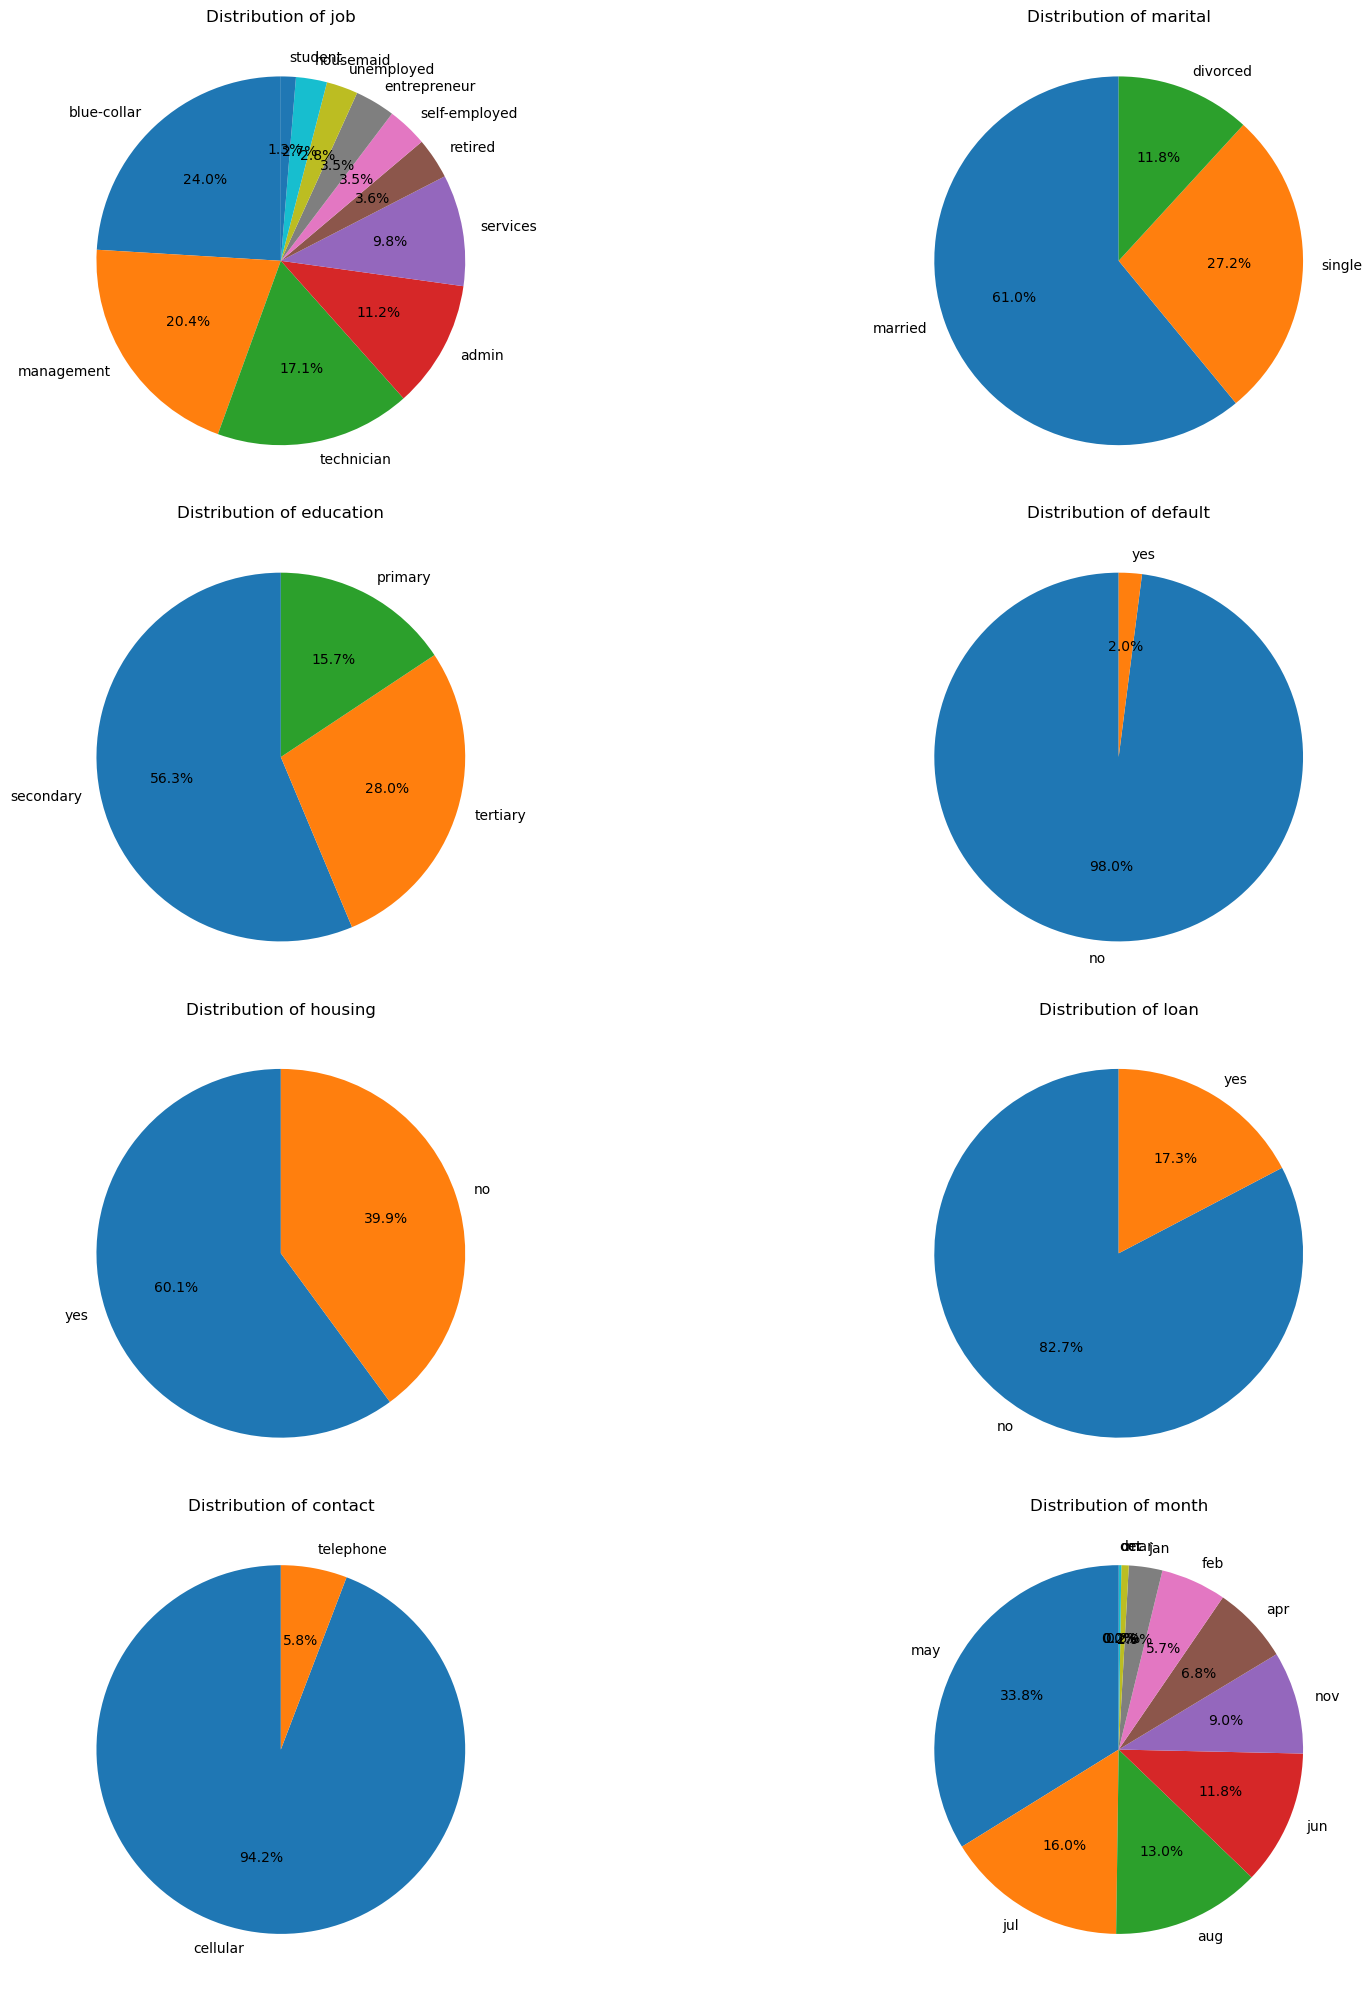

In [23]:
plt.figure(figsize=(20, 20))

for i, col in enumerate(categorical_features, start=1):
    plt.subplot(4, 2, i)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%.1f%%', startangle=90)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## Categorical Feature Insights

### Month
- There is a **massive surge in calls during May**
- This indicates that the campaign activity is **heavily concentrated in May**, likely reflecting strategic timing or historical success during this month

---

### Job
- The tallest bars correspond to:
  - **Blue-collar**
  - **Management**
  - **Technician**
- These roles form the **primary target segments** of the campaign

---

### Education
- A **vast majority** of contacted customers have **secondary education**
- This suggests the campaign predominantly targets individuals with mid-level educational backgrounds

---

### Marital
- Most contacted customers are **married**
- Married individuals appear to be a key demographic segment for term deposit marketing

---

### Default
- A **vast majority** of customers **do not have credit in default**
- This aligns with typical banking strategies that prioritize lower-risk customers

---

### Loan
- Most contacted customers **do not have a personal loan**
- Customers without existing loan obligations may be more receptive to term deposit offers

---

### Housing
- A **vast majority** of customers **have a housing loan**
- This may indicate stable, long-term banking relationships

---

### Contact
- Most customers were contacted via **cellular**
- This confirms cellular outreach as the **primary communication channel** for the campaign


## Numeric Univariate Analysis

In [24]:
df.describe()

,age,balance,day,duration,campaign,y
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175,0.072400
std,9.641776,2903.769716,8.278127,259.366498,3.239051,0.259152
min,19.000000,-8019.000000,1.000000,0.000000,1.000000,0.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000,0.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000,0.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,1.000000


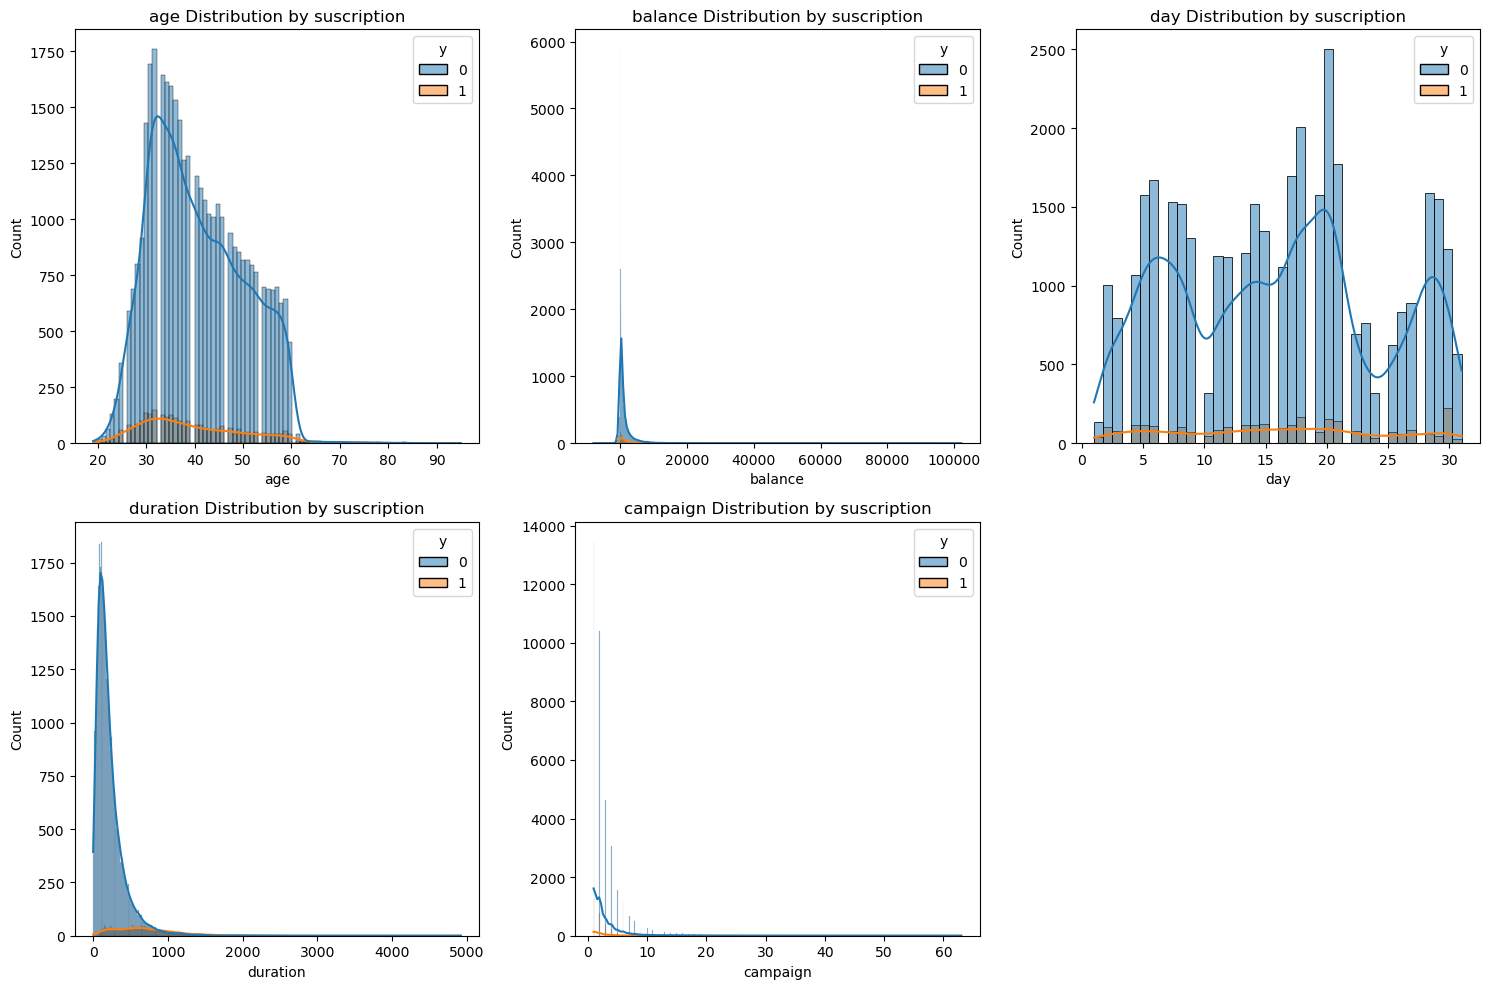

In [25]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_features, start=1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df,x=col,hue='y',kde=True)
    plt.title(f'{col} Distribution by suscription')

plt.tight_layout()
plt.show()

## Numerical Feature Insights

### Age
- The average customer age is **40 years**
- Most customers fall within the **33–48** age range
- The maximum age of **95** indicates a small segment of **retirees or elderly customers**
- Age appears reasonably distributed with mild right skew

---

### Balance
- The mean balance is **1,274**, but the standard deviation is extremely high (**2,903**), indicating substantial variability
- Values range from **–8,019** to **102,127**, revealing a **highly right-skewed distribution** with significant outliers
- This suggests a customer base that includes individuals in **heavy debt** as well as a small group of **exceptionally wealthy** customers
- Outlier handling may be necessary

---

### Day

- The distribution shows spikes around the **middle of the month**
- This suggests that the sales team is **most aggressive during mid-month periods**

---

### Duration
- Represents the **last contact duration** in seconds
- Mean duration is **254 seconds** (~4 minutes)
- Maximum duration is **4,918 seconds** (~82 minutes), indicating a long-tail distribution

**Important Note:**  
- `Duration` is a **leaky feature**
- Longer calls often occur *because* the customer is interested, making it a strong predictor
- However, it is only known **after** the call begins and should be excluded from models intended for **pre-call decision-making**

---

### Campaign
- On average, customers were contacted **~2.8 times** during the campaign
- One customer was contacted **63 times**, which is likely excessive
- Extremely high contact counts may indicate poor targeting and could contribute to **customer dissatisfaction**

## Categoric-Categoric Bivariate Analysis

In [26]:
chi2_results = []

for col1, col2 in combinations(categorical_features, 2):
    table = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(table)
    
    chi2_results.append({
        'Variable 1': col1,
        'Variable 2': col2,
        'Chi2 Statistic': chi2,
        'p-value': p
    })

chi2_df = pd.DataFrame(chi2_results)

chi2_df = chi2_df.sort_values('p-value').reset_index(drop=True)

chi2_df

,Variable 1,Variable 2,Chi2 Statistic,p-value
0,job,marital,2617.206711,0.000000e+00
1,housing,month,10213.366091,0.000000e+00
2,job,month,4871.026283,0.000000e+00
3,contact,month,1806.138087,0.000000e+00
4,job,education,23759.437146,0.000000e+00
5,job,housing,1923.921815,0.000000e+00
6,education,month,1464.696341,1.490352e-298
7,loan,month,1349.161313,9.372307e-284
8,marital,education,1119.975337,3.543228e-241
9,marital,month,560.246213,6.677095e-106


The variables job, education, month, marital, and housing are strongly linked and may contain overlapping socioeconomic information. After encoding, this dependence may introduce multicollinearity and redundant signals, which can affect model stability and interpretability.

## Numeric-Numeric Bivariate Analysis

C:\Users\Prashal\miniconda3\envs\ds\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\Prashal\AppData\Local\Temp\ipykernel_20680\3573797225.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


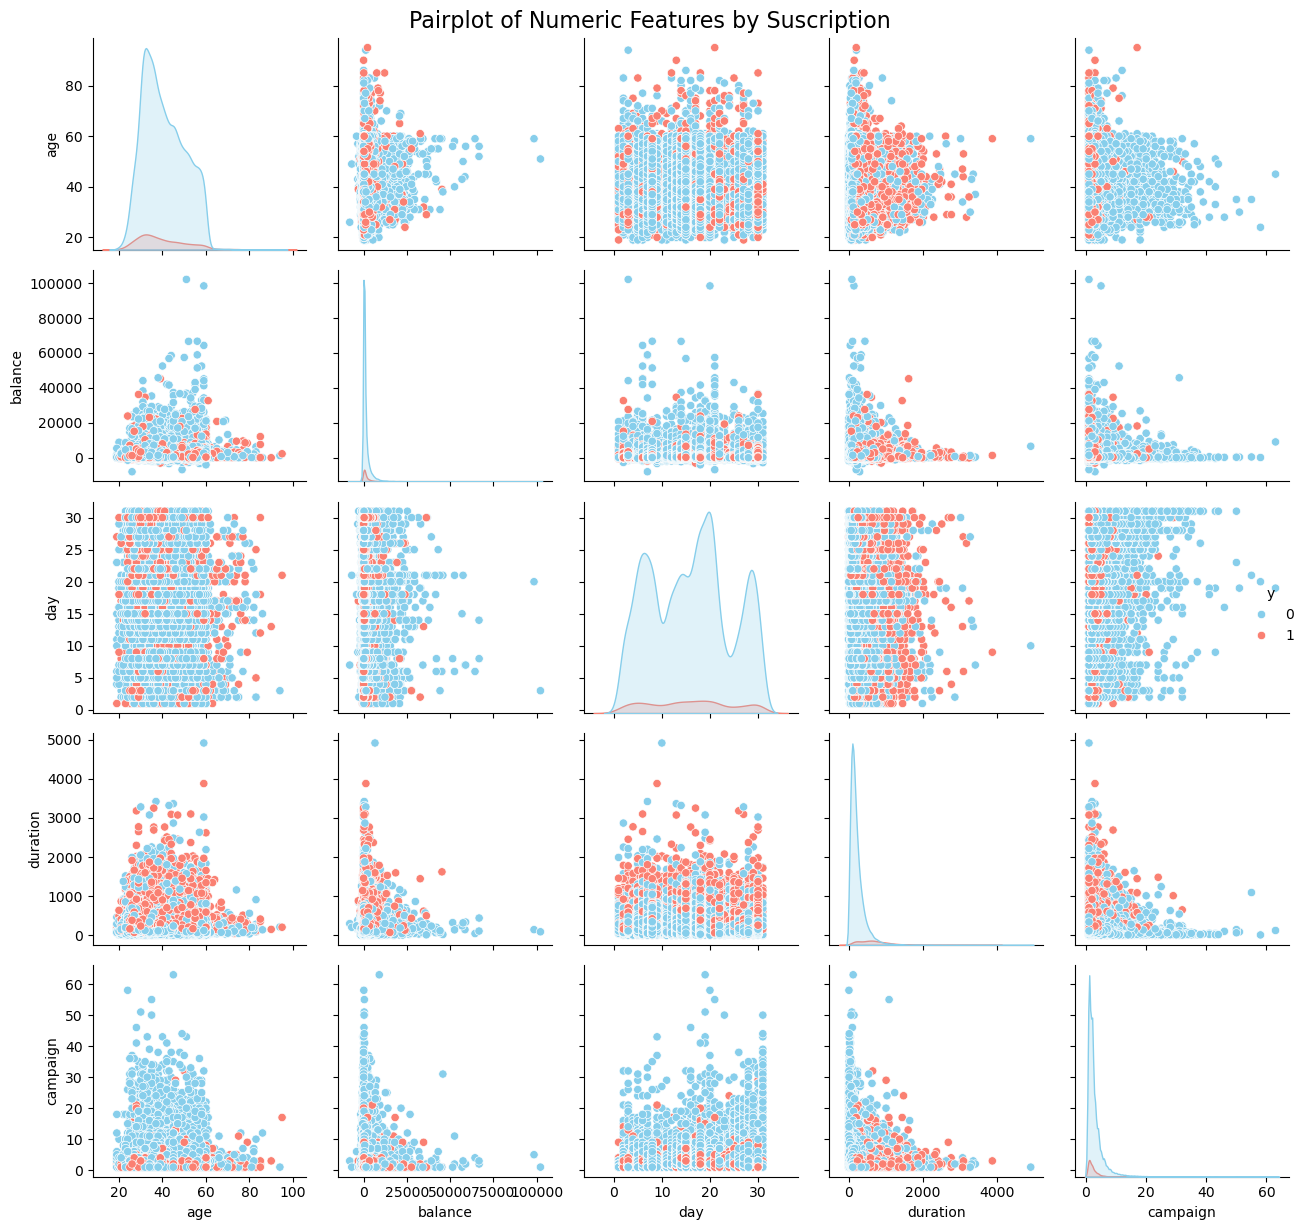

In [27]:
g=sns.pairplot(df[numeric_features + ['y']],hue='y',palette={0: "skyblue", 1: "salmon"})
g.fig.subplots_adjust(top=0.95) 
g.fig.suptitle("Pairplot of Numeric Features by Suscription", fontsize=16)
plt.tight_layout()
plt.show()

Outliers are present across several numerical features, which can negatively impact model performance by dominate learning and reduce generalization.

## Numeric Multivariate Analysis

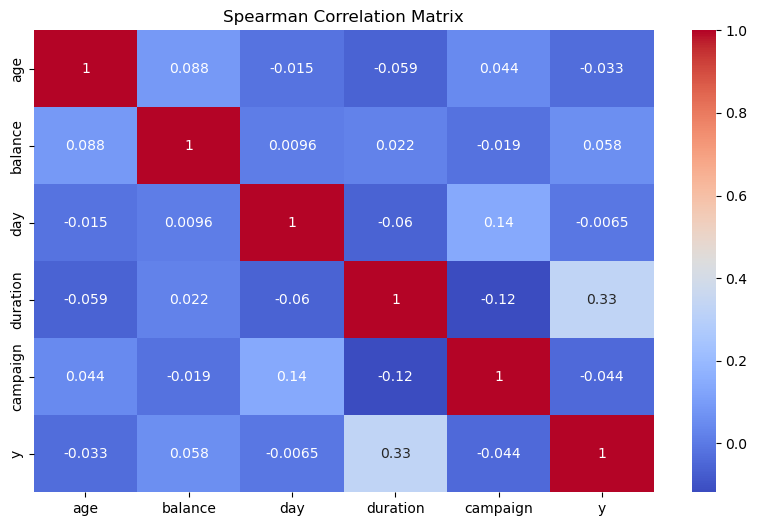

In [28]:
plt.figure(figsize=(10, 6))
correlation = df[numeric_features + ['y']].corr(method='spearman')
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Spearman Correlation Matrix')
plt.show()

## Heatmap Insights

- Most numeric features show **weak or no strong correlations** with each other
- This suggests limited multicollinearity and indicates that many features contribute **independent information** to the model
- There is a **moderate positive correlation** between **`duration`** and the target variable `y`
- Logically, as **call duration increases**, the **probability of a “Yes” outcome rises significantly**
- As a result, `duration` becomes a **powerful predictor** of subscription
- Despite its predictive strength, `duration` is a **leaky variable**
- It should be excluded from models intended for **pre-call targeting**, but may be useful for **post-call analysis**


## Outlier Handling

Since our data is not normally distributed, we will prefer using IQR method over Z-score based outlier detection. Since our data is skewed, we will combine IQR with Winsorization to replace the outliers with specific percentile values (capping) rather than deleting them to avoid throwing away potentially valuable, albeit extreme, data points.

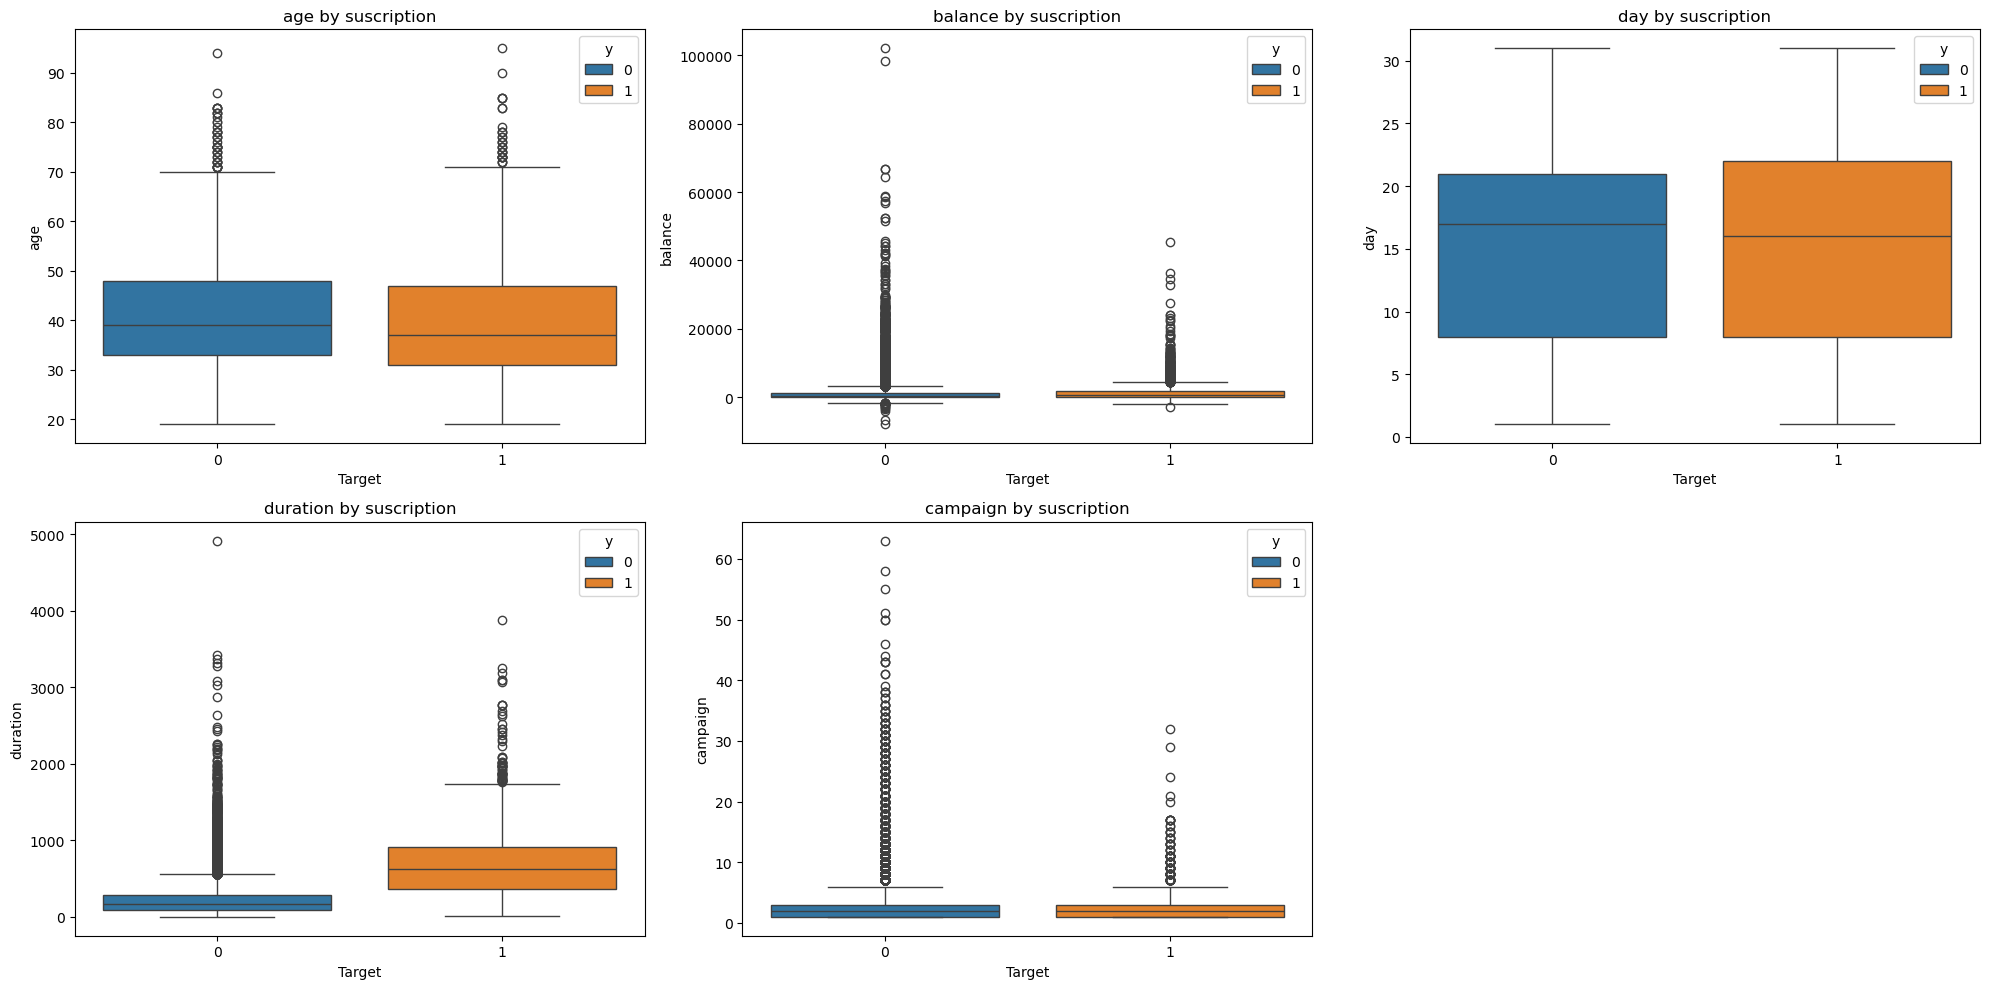

In [29]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(numeric_features, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=y, y=df[col], hue=y)
    plt.title(f'{col} by suscription')
    plt.xlabel('Target')

plt.tight_layout()
plt.show()

In [30]:
df_out = df.copy()
    
for col in numeric_features:
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
        
    #df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    df_out[col] = np.where(df_out[col] < lower_bound, lower_bound, df_out[col])
    df_out[col] = np.where(df_out[col] > upper_bound, upper_bound, df_out[col])
    
X = df_out.drop(columns=['y'])
y = df_out['y']

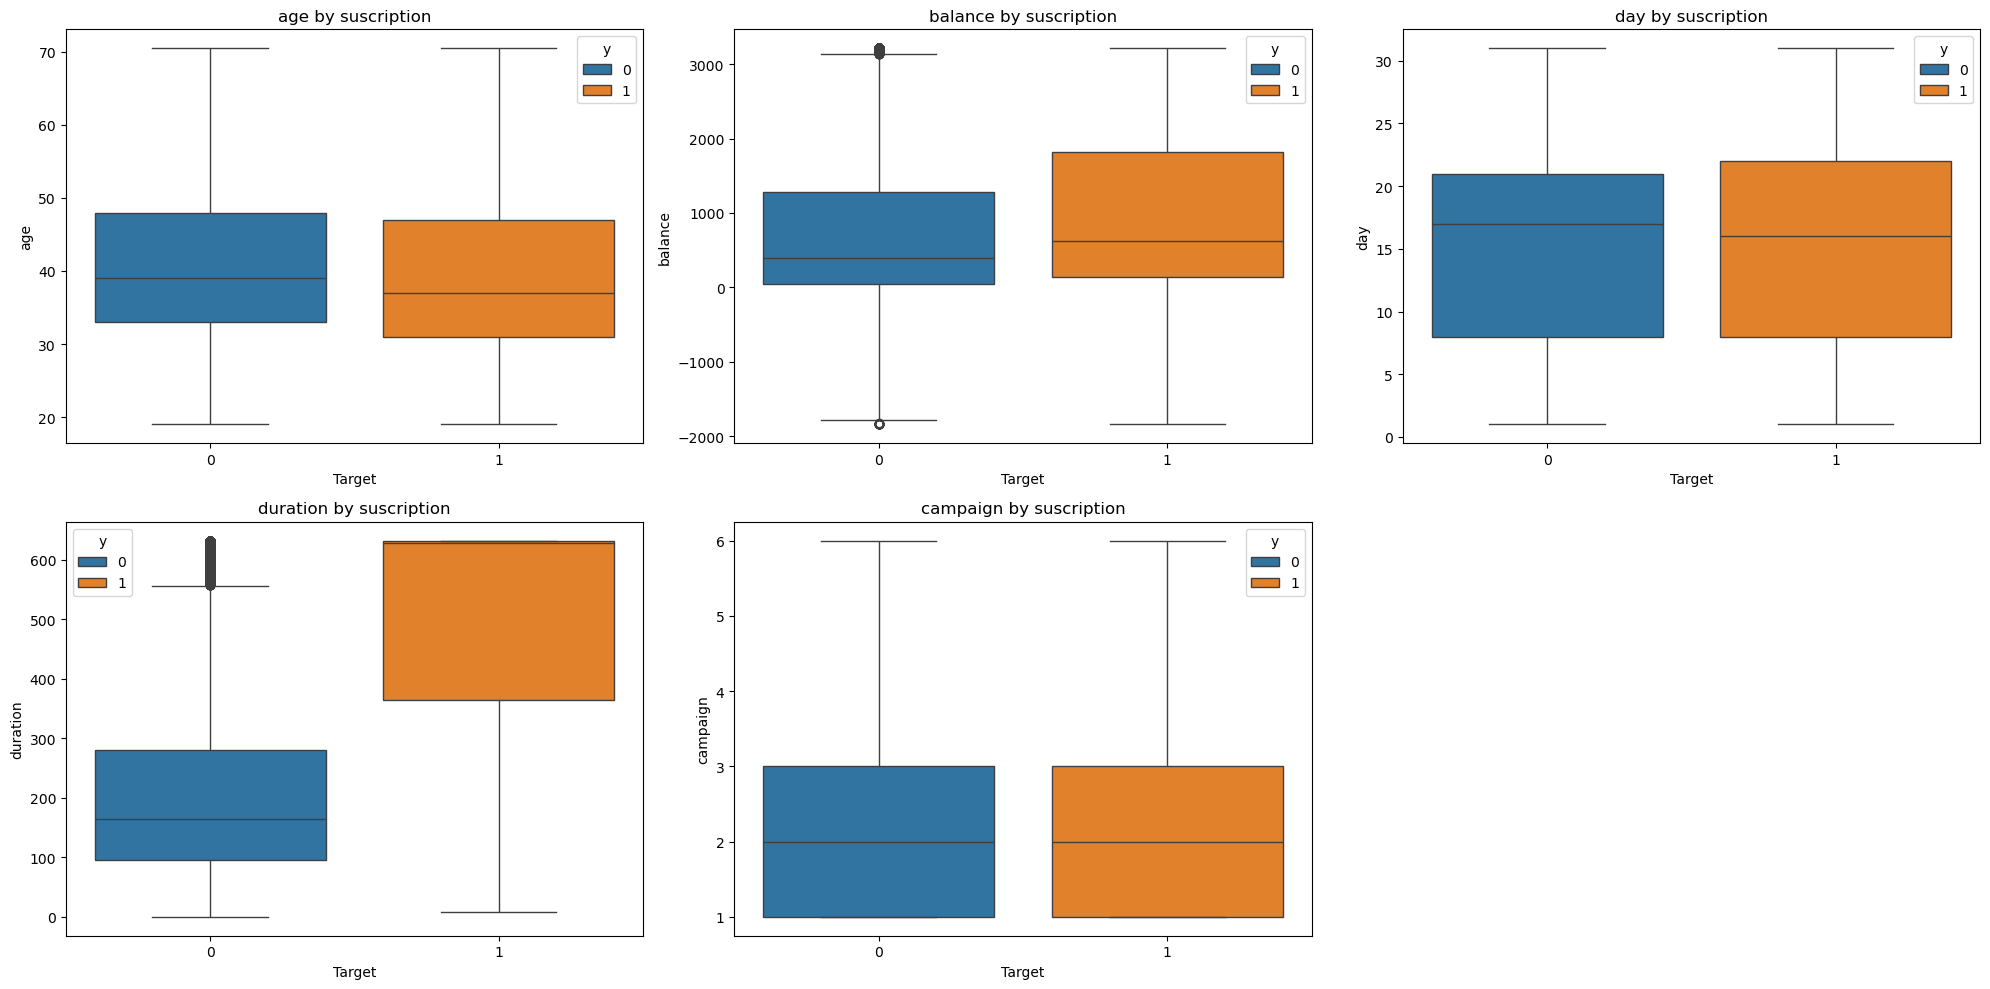

In [31]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(numeric_features, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=y, y=df_out[col], hue=y)
    plt.title(f'{col} by suscription')
    plt.xlabel('Target')

plt.tight_layout()
plt.show()

In [32]:
zero_variance_cols = [col for col in X.columns if X[col].nunique() <= 1]
print("Zero Variance Columns:", zero_variance_cols)

singleton_cols = []
for col in categorical_features:
    value_counts = X[col].value_counts()
    if any(value_counts == 1):
        singleton_cols.append(col)
print("Columns with Singleton Categories:", singleton_cols)

Zero Variance Columns: []
Columns with Singleton Categories: []


There are no columns with Zero Variance and Singleton Categories.

## Model Training

### Data Splitting Strategy

To properly evaluate performance under class imbalance:

- **80% Training + Validation**
- **20% Test Set**

Further split training into:

- **60% Train**
- **20% Validation**

**Stratified sampling** was used in all splits to preserve the original ~7.2% positive class distribution.

---

### Preprocessing Pipeline

A `ColumnTransformer` was applied:

- **Numerical Features → MinMaxScaler**: Chosen over StandardScaler because features were not normally distributed.

- **Categorical Features → Binary Encoding**: Preferred over One-Hot Encoding to reduce dimensionality and prevent feature explosion.


In [33]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', ce.BinaryEncoder(), categorical_features)
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

### Models Evaluated

Given the extreme class imbalance, multiple baseline and imbalance-aware models were tested:

- Decision Tree  
- Gaussian Naive Bayes  
- Random Forest  
- KNN  
- SVM  
- Logistic Regression  
- Balanced Random Forest  
- XGBoost  
- RUSBoost  

Each model was evaluated on:

- **Accuracy**
- **ROC–AUC (Primary Metric)**

ROC–AUC was emphasized because accuracy is misleading in highly imbalanced settings.

In [34]:
brf = BalancedRandomForestClassifier(n_estimators=300,random_state=42,class_weight={0:0.53903513,1:6.90448792})

rbc = RUSBoostClassifier(random_state=42,estimator=RandomForestClassifier(),n_estimators=300,sampling_strategy=float(y_train.value_counts()[1]/y_train.value_counts()[0]),algorithm="SAMME")

xgb = XGBClassifier(n_estimators=300,random_state=24,n_jobs=2,scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1])

dt = DecisionTreeClassifier(min_samples_leaf=2,criterion="gini",max_depth=7,random_state=42,class_weight="balanced")

gnb = GaussianNB()

rf = RandomForestClassifier(n_estimators=300,max_depth=10,class_weight="balanced_subsample",random_state=42)

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

svm = SVC(C=1.0, class_weight="balanced", probability=True, random_state=42)

log_reg = LogisticRegression(class_weight="balanced", max_iter=5000)

models = [dt, gnb, rf, knn, svm, log_reg, brf, xgb, rbc]


-------- DecisionTreeClassifier --------
Val ROC-AUC: 0.9002
Test ROC-AUC: 0.9039

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      7421
           1       0.31      0.85      0.45       579

    accuracy                           0.85      8000
   macro avg       0.65      0.85      0.68      8000
weighted avg       0.94      0.85      0.88      8000



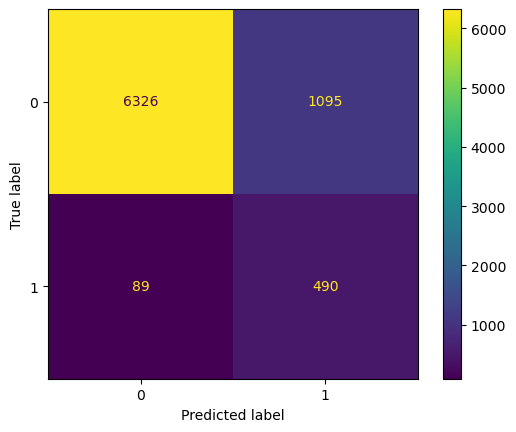

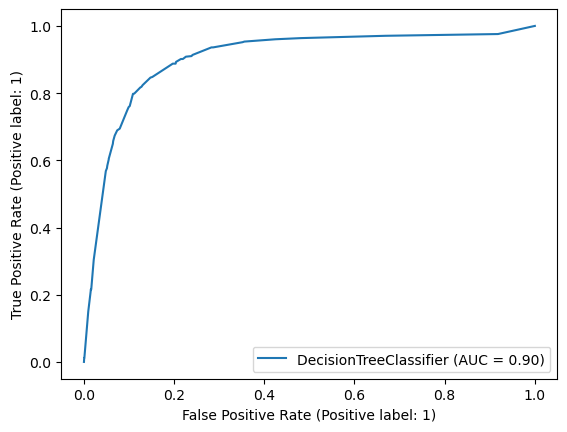


-------- GaussianNB --------
Val ROC-AUC: 0.8817
Test ROC-AUC: 0.8792

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7421
           1       0.33      0.43      0.37       579

    accuracy                           0.90      8000
   macro avg       0.64      0.68      0.66      8000
weighted avg       0.91      0.90      0.90      8000



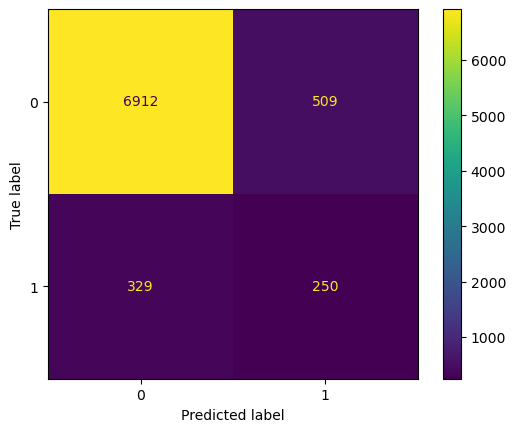

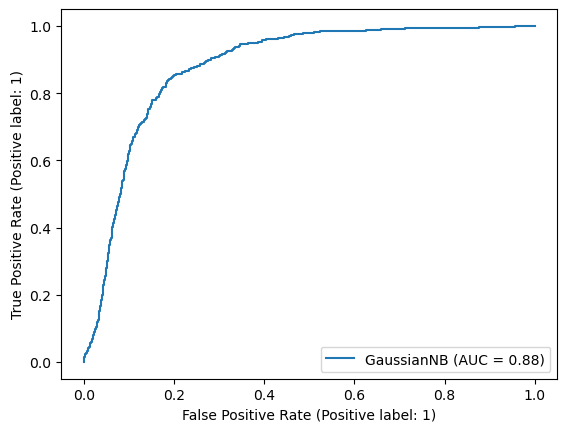


-------- RandomForestClassifier --------
Val ROC-AUC: 0.9352
Test ROC-AUC: 0.9276

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      7421
           1       0.38      0.78      0.51       579

    accuracy                           0.89      8000
   macro avg       0.68      0.84      0.73      8000
weighted avg       0.94      0.89      0.91      8000



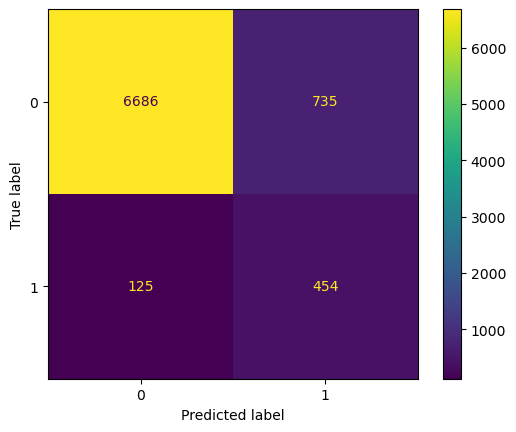

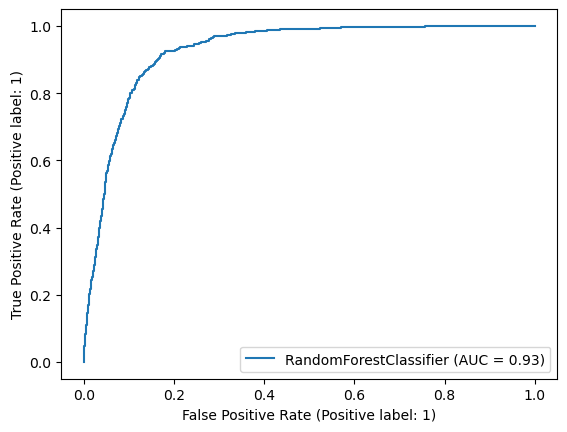


-------- KNeighborsClassifier --------
Val ROC-AUC: 0.7854
Test ROC-AUC: 0.7645

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7421
           1       0.45      0.17      0.25       579

    accuracy                           0.93      8000
   macro avg       0.70      0.58      0.60      8000
weighted avg       0.90      0.93      0.91      8000



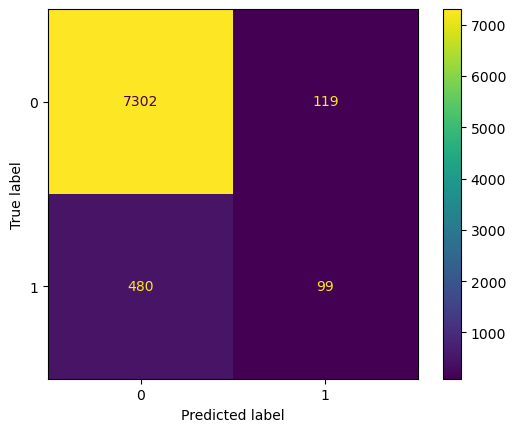

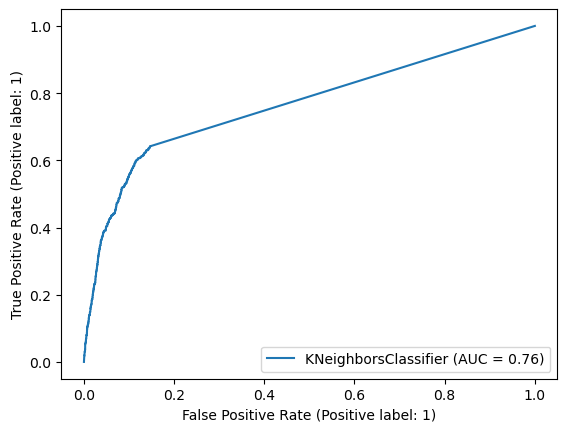


-------- SVC --------
Val ROC-AUC: 0.9325
Test ROC-AUC: 0.9233

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      7421
           1       0.31      0.86      0.46       579

    accuracy                           0.85      8000
   macro avg       0.65      0.86      0.69      8000
weighted avg       0.94      0.85      0.88      8000



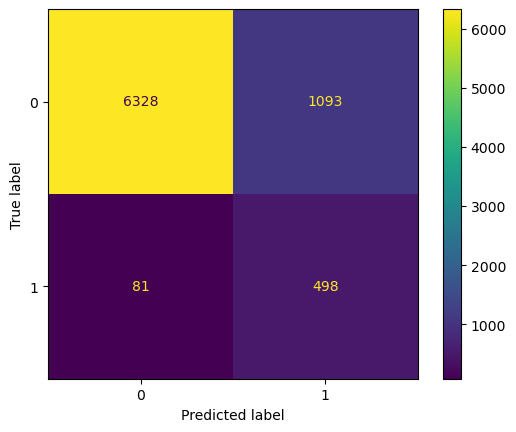

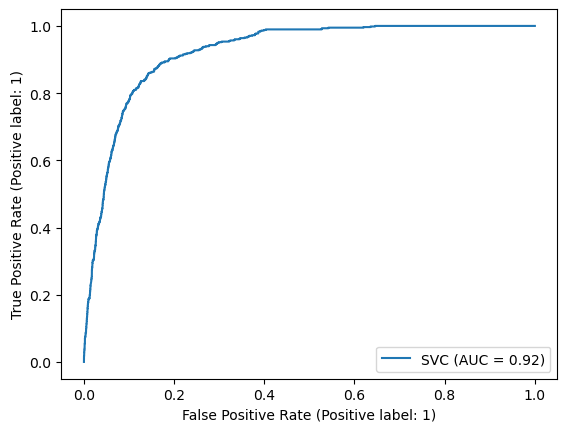


-------- LogisticRegression --------
Val ROC-AUC: 0.9155
Test ROC-AUC: 0.9123

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      7421
           1       0.28      0.86      0.43       579

    accuracy                           0.83      8000
   macro avg       0.63      0.84      0.66      8000
weighted avg       0.94      0.83      0.87      8000



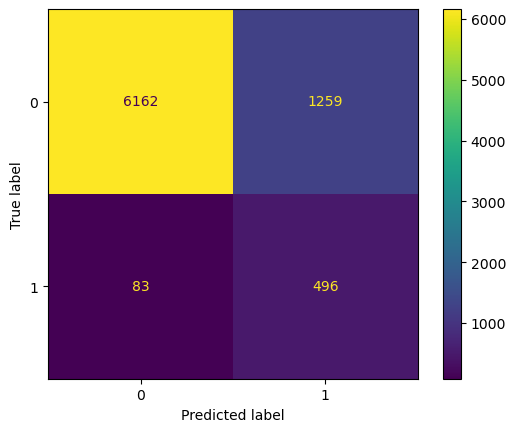

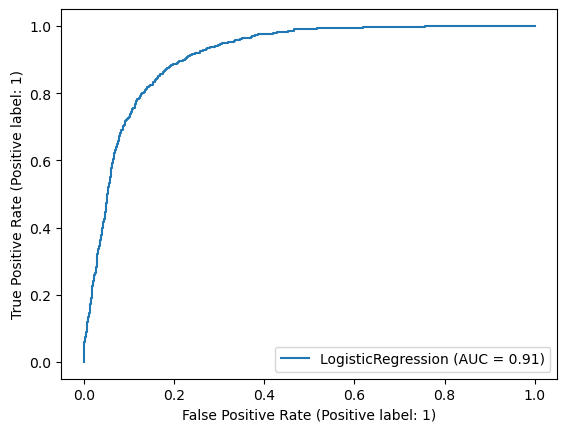


-------- BalancedRandomForestClassifier --------
Val ROC-AUC: 0.9328
Test ROC-AUC: 0.9262

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      7421
           1       0.36      0.84      0.50       579

    accuracy                           0.88      8000
   macro avg       0.67      0.86      0.72      8000
weighted avg       0.94      0.88      0.90      8000



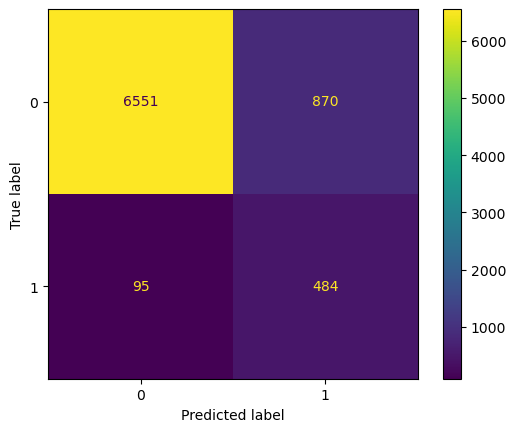

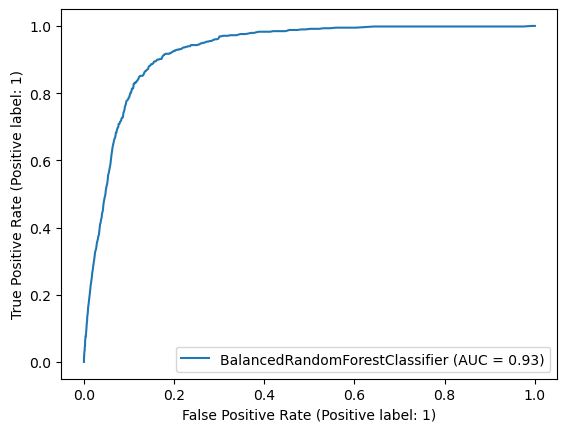


-------- XGBClassifier --------
Val ROC-AUC: 0.9297
Test ROC-AUC: 0.9237

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      7421
           1       0.44      0.54      0.48       579

    accuracy                           0.92      8000
   macro avg       0.70      0.74      0.72      8000
weighted avg       0.93      0.92      0.92      8000



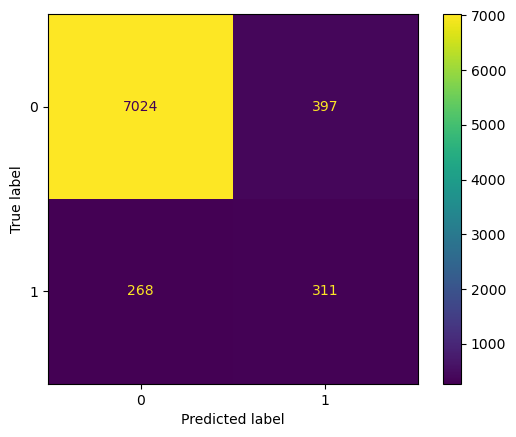

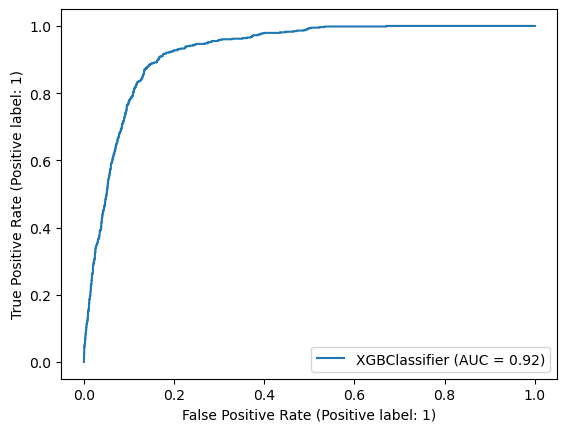


-------- RUSBoostClassifier --------


C:\Users\Prashal\miniconda3\envs\ds\lib\site-packages\imblearn\ensemble\_weight_boosting.py:402: FutureWarning: `algorithm` parameter is deprecated in 0.12 and will be removed in 0.14. In the future, the SAMME algorithm will always be used.
  warnings.warn(


Val ROC-AUC: 0.6120
Test ROC-AUC: 0.6021

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      7421
           1       0.56      0.22      0.31       579

    accuracy                           0.93      8000
   macro avg       0.75      0.60      0.64      8000
weighted avg       0.91      0.93      0.92      8000



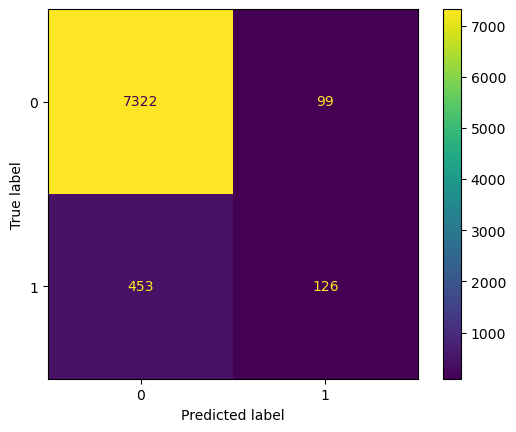

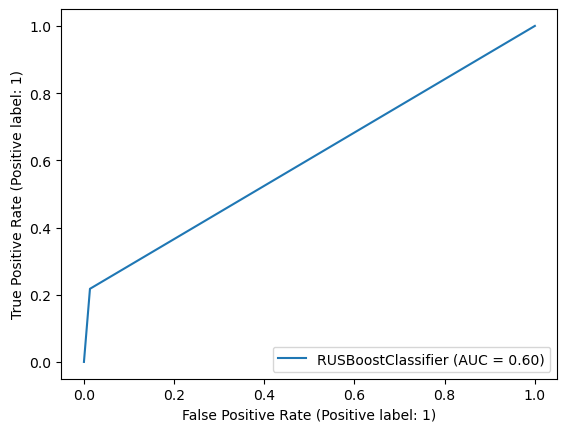

In [36]:
performance_results = {
    "train": [],
    "val": [],
    "test": []
}

datasets = {
    "train": (X_train_p, y_train),
    "val": (X_val_p, y_val),
    "test": (X_test_p, y_test)
}

for model in models:
    
    model_name = type(model).__name__
    print(f"\n-------- {model_name} --------")
    
    model.fit(X_train_p, y_train)
    
    for split_name, (X_split, y_split) in datasets.items():
        
        y_pred = model.predict(X_split)
        y_proba = model.predict_proba(X_split)[:, 1]
        
        accuracy = accuracy_score(y_split, y_pred)
        roc_auc = roc_auc_score(y_split, y_proba)
        
        performance_results[split_name].append({
            "Model_name": model_name,
            "Accuracy": accuracy,
            "ROC_AUC": roc_auc
        })
        
        if split_name in ["val", "test"]:
            print(f"{split_name.capitalize()} ROC-AUC: {roc_auc:.4f}")
    
    print("\nClassification Report (Test):")
    print(classification_report(y_test, model.predict(X_test_p)))
    
    ConfusionMatrixDisplay.from_estimator(model, X_test_p, y_test)
    plt.show()
    
    RocCurveDisplay.from_estimator(model, X_test_p, y_test)
    plt.show()

performance_results_train = pd.DataFrame(performance_results["train"])
performance_results_val   = pd.DataFrame(performance_results["val"])
performance_results_test  = pd.DataFrame(performance_results["test"])

### Initial Model Comparison

#### Key Observations:

- Best ROC–AUC performers (Validation/Test):
  - **RandomForestClassifier (~0.93)**
  - **BalancedRandomForestClassifier (~0.93)**
  - **XGBClassifier (~0.92)**

- RUSBoost performed poorly (**ROC–AUC ~0.60**)
- KNN showed high accuracy but weak minority recall

Based on ROC–AUC stability and generalization:

➡ Selected **RF, BRF, and XGB** for further validation.


In [37]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'accuracy': 'accuracy','roc_auc': 'roc_auc'}

models = [rf, brf, xgb]

for model in models:
    model_name = type(model).__name__
    
    cv_results = cross_validate(
        model,
        X_train_p,
        y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1
    )
    
    print(f"\n----- {model_name} -----")
    print("Accuracy:", cv_results['test_accuracy'].mean())
    print("ROC AUC:", cv_results['test_roc_auc'].mean())


----- RandomForestClassifier -----
Accuracy: 0.8944583333333334
ROC AUC: 0.929223112051383

----- BalancedRandomForestClassifier -----
Accuracy: 0.8781250000000002
ROC AUC: 0.929389063849206

----- XGBClassifier -----
Accuracy: 0.919125
ROC AUC: 0.920307825755496


### Cross-Validation (5-Fold Stratified)

Performed cross-validation using **ROC–AUC as the refit metric**.

XGBoost showed slightly lower ROC-AUC Score than Random Forest and Balanced Random Forest.

➡ Advanced **RF and BRF** for hyperparameter tuning.

In [39]:
rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced_subsample", random_state=42),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring=scoring,
    refit='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_p, y_train)

print("Best RF Params:", rf_random.best_params_)
print("Best RF CV Score:", rf_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30}
Best RF CV Score: 0.9335281661519167


In [40]:
brf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

brf_random = RandomizedSearchCV(
    estimator=BalancedRandomForestClassifier(random_state=42, class_weight={0:0.53903513,1:6.90448792}),
    param_distributions=brf_param_grid,
    n_iter=30,
    scoring=scoring,
    refit='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

brf_random.fit(X_train_p, y_train)

print("Best BRF Params:", brf_random.best_params_)
print("Best BRF CV Score:", brf_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best BRF Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best BRF CV Score: 0.9280863135376487



--- RandomForestClassifier Test Performance ---
Accuracy: 0.9155
ROC AUC: 0.9322971104499926

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      7421
           1       0.45      0.72      0.55       579

    accuracy                           0.92      8000
   macro avg       0.71      0.83      0.75      8000
weighted avg       0.94      0.92      0.92      8000



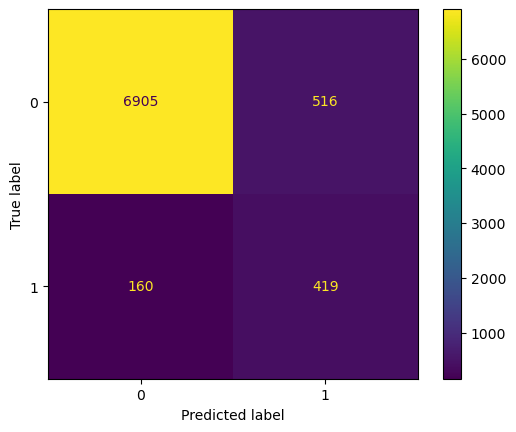

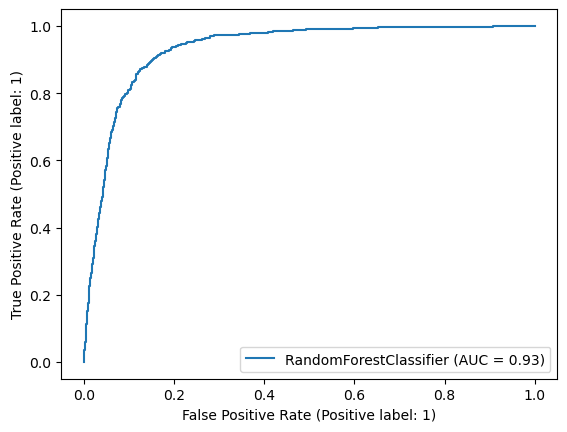


--- BalancedRandomForestClassifier Test Performance ---
Accuracy: 0.880375
ROC AUC: 0.9259183491557239

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      7421
           1       0.36      0.83      0.50       579

    accuracy                           0.88      8000
   macro avg       0.67      0.86      0.72      8000
weighted avg       0.94      0.88      0.90      8000



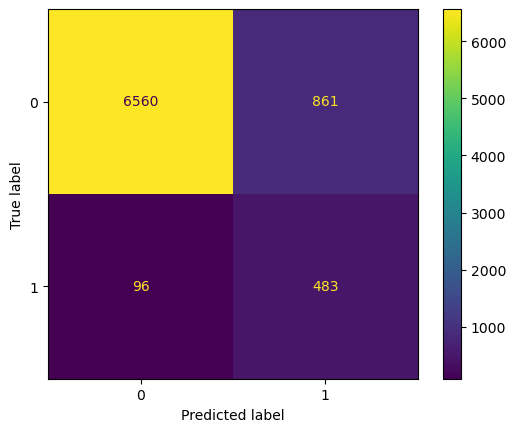

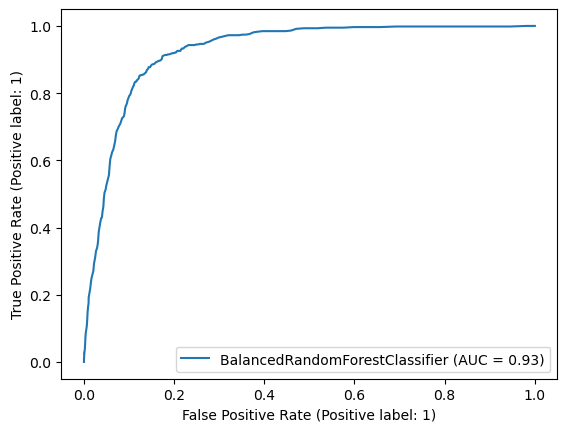

In [62]:
best_rf = rf_random.best_estimator_
best_brf = brf_random.best_estimator_

for model in [best_rf, best_brf]:
    model_name = type(model).__name__
    
    y_pred = model.predict(X_test_p)
    y_proba = model.predict_proba(X_test_p)[:,1]
    
    print(f"\n--- {model_name} Test Performance ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))

    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred))
    
    ConfusionMatrixDisplay.from_estimator(model, X_test_p, y_test)
    plt.show()

    RocCurveDisplay.from_estimator(model, X_test_p, y_test)
    plt.show()

### Hyperparameter Tuning (RandomizedSearchCV)

Optimized both RF and BRF using:

- **5-Fold Cross Validation**
- **30 Random Search Iterations**
- Refit based on **ROC–AUC**

Random forest has a better score than Balanced Random Forest. So, Random forest was selected as the final model to be trained with reduced features.

### Feature Importance & Dimensionality Reduction

In [46]:
feature_names = preprocessor.get_feature_names_out()
importances = best_rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_k = 10
selected_features = importance_df.head(top_k)["Feature"].values

print("Top Features for RandomForestClassifier:")
print(selected_features)

Top Features for RandomForestClassifier:
['num__duration' 'num__day' 'num__balance' 'num__age' 'cat__month_3'
 'num__campaign' 'cat__month_2' 'cat__month_1' 'cat__month_0'
 'cat__housing_1']


In [47]:
selected_indices = [
    np.where(feature_names == feat)[0][0]
    for feat in selected_features
]

X_train_reduced = X_train_p[:, selected_indices]
X_val_reduced   = X_val_p[:, selected_indices]
X_test_reduced  = X_test_p[:, selected_indices]


--- Final Test Performance:
Accuracy: 0.91825
ROC AUC: 0.9376628989431336

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      7421
           1       0.46      0.74      0.57       579

    accuracy                           0.92      8000
   macro avg       0.72      0.84      0.76      8000
weighted avg       0.94      0.92      0.93      8000



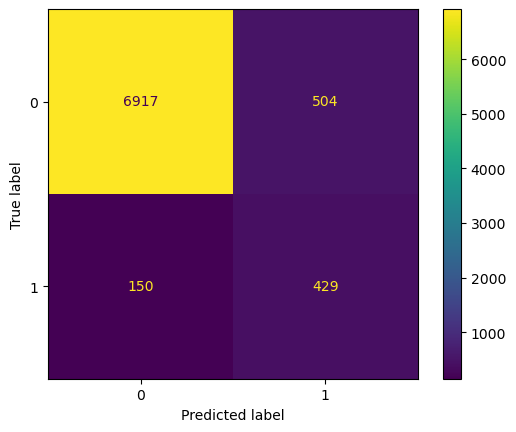

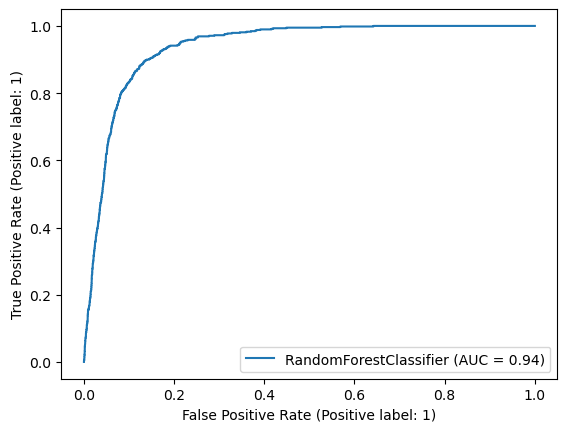

In [138]:
rf_reduced = RandomForestClassifier(
    **rf_random.best_params_,
    class_weight="balanced_subsample",
    random_state=42
)

rf_reduced.fit(X_train_reduced, y_train)

y_test_pred  = rf_reduced.predict(X_test_reduced)
y_test_proba = rf_reduced.predict_proba(X_test_reduced)[:, 1]

print("\n--- Final Test Performance:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_proba))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))
    
ConfusionMatrixDisplay.from_estimator(rf_reduced, X_test_reduced, y_test)
plt.show()

RocCurveDisplay.from_estimator(rf_reduced, X_test_reduced, y_test)
plt.show()

Performance improved slightly while reducing feature dimensionality.

## Clustering

In [95]:
df_positive = df_out[df_out['y'] == 1].copy()
print("Number of positive customers:", df_positive.shape[0])

Number of positive customers: 2896


In [113]:
X_positive=df_positive.drop('y',axis=1)
Y_positive=df_positive['y']

X_positive_scaled = preprocessor.fit_transform(X_positive)
feature_names = preprocessor.get_feature_names_out()
X_positive_scaled = pd.DataFrame(X_positive_scaled, columns=feature_names)

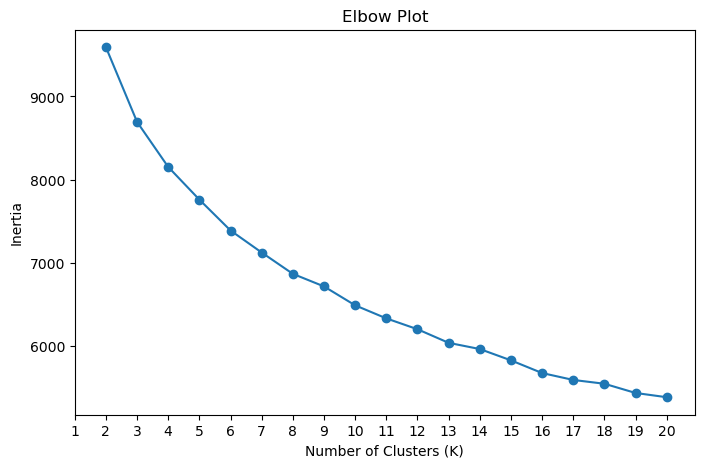

In [97]:
inertia = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_positive_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 21), inertia, 'o-')
plt.xticks(range(1, 21))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.show()

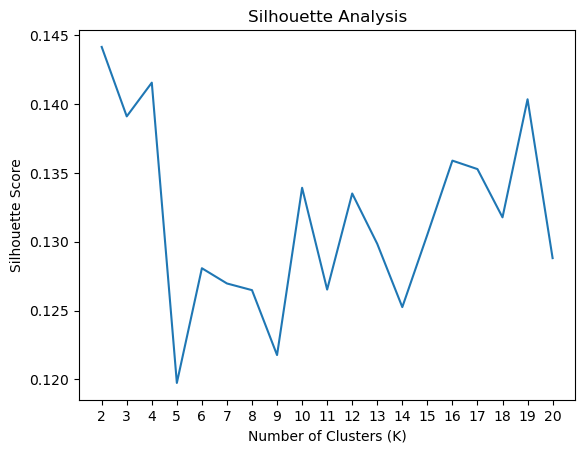

In [98]:
silhouette_scores = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_positive_scaled)
    score = silhouette_score(X_positive_scaled, labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(range(2, 21), silhouette_scores)
plt.xlabel("Number of Clusters (K)")
plt.xticks(range(2, 21))
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

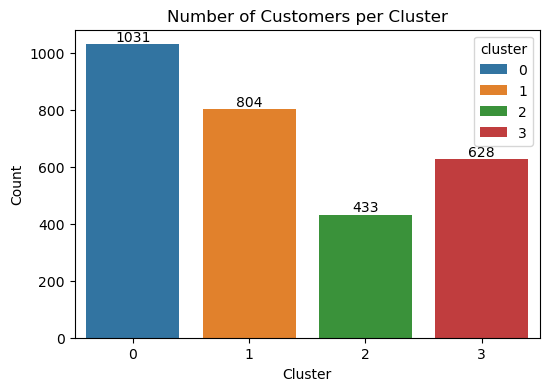

In [144]:
k_optimal = 4

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_positive['cluster'] = kmeans.fit_predict(X_positive_scaled)

plt.figure(figsize=(6,4))
ax = sns.countplot(x='cluster', data=df_positive, hue='cluster', palette=['tab:blue','tab:orange','tab:green','tab:red'])\
for container in ax.containers:
    ax.bar_label(container)
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks([0,1,2,3])
plt.show()

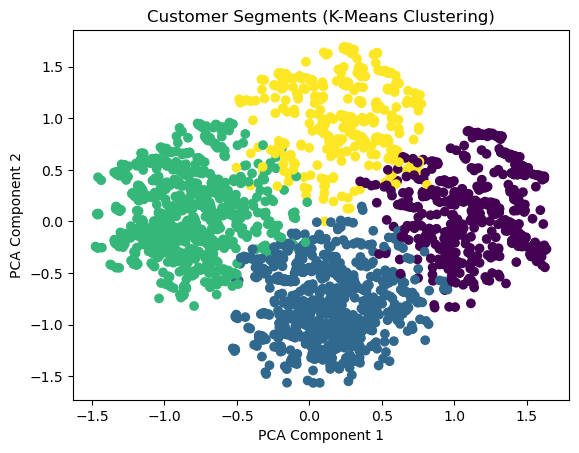

In [100]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_positive_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_positive['cluster'])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments (K-Means Clustering)")
plt.show()

In [146]:
cluster_summary = df_positive.groupby('cluster')[numeric_features].mean()
cluster_summary

,age,balance,day,duration,campaign
cluster,,,,,
0,38.371484,886.123666,15.451988,550.046557,2.170708
1,42.999378,1110.714552,16.160448,463.180348,2.187811
2,37.040416,1153.534642,15.810624,506.285219,2.173210
3,39.804936,1302.442675,16.027070,438.496019,2.361465


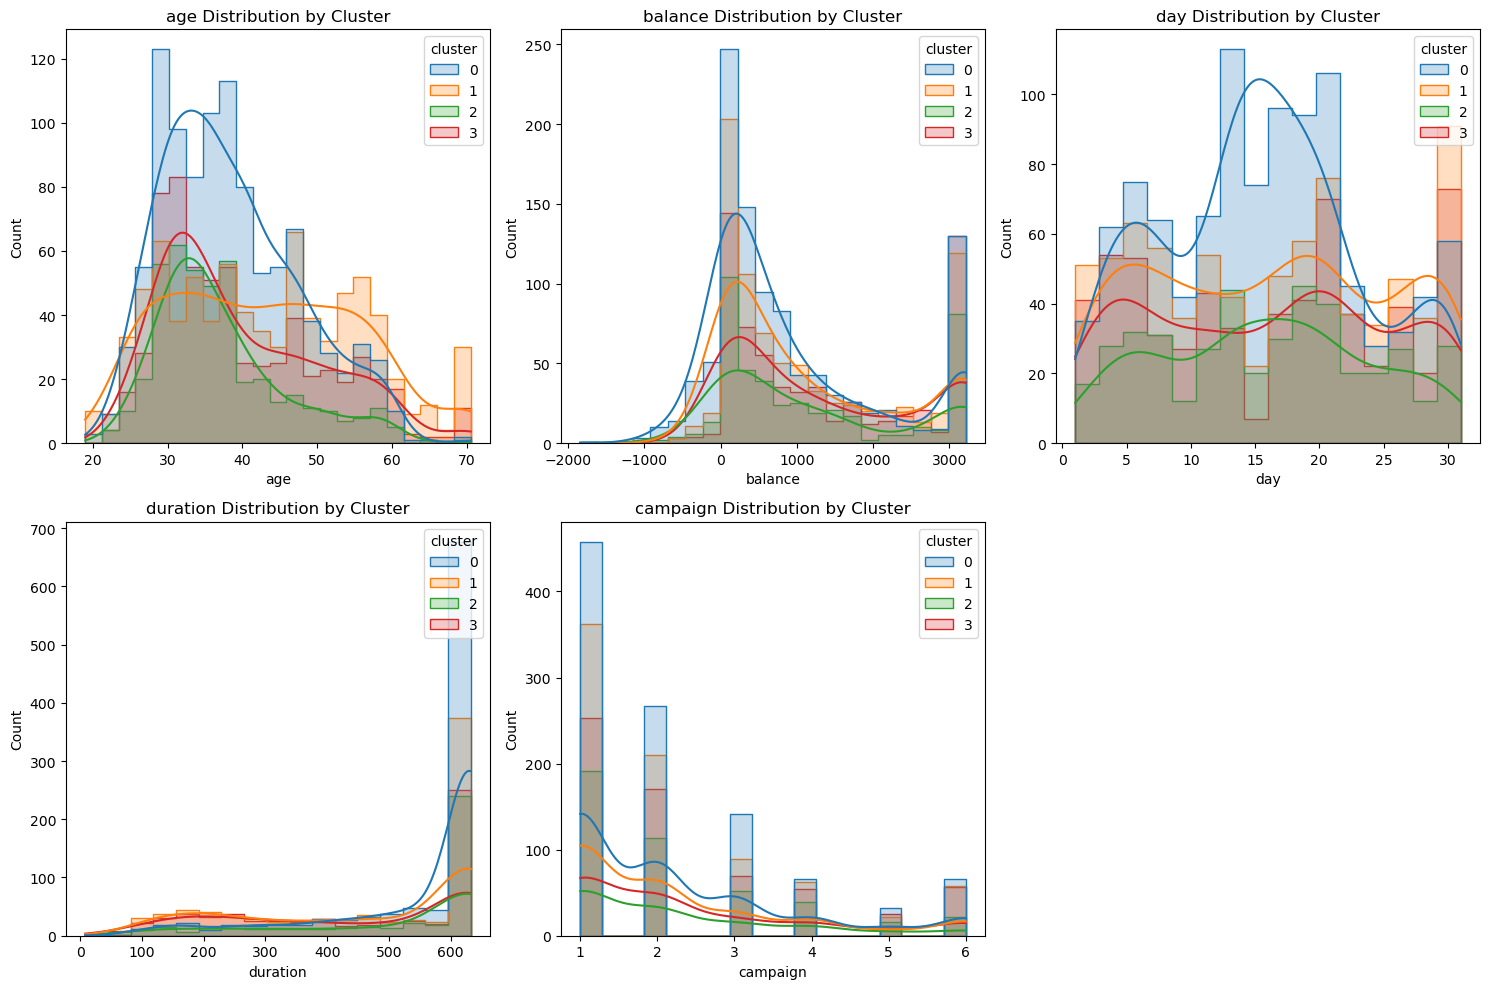

In [135]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_features, start=1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df_positive, x=col, element='step', hue='cluster', palette=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'], kde=True)
    plt.title(f'{col} Distribution by Cluster')

plt.tight_layout()
plt.show()

In [123]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(pd.crosstab(df_positive[col], df_positive['cluster'], normalize='columns'))


--- job ---
cluster               0         1         2         3
job                                                  
admin          0.173618  0.152985  0.041570  0.049363
blue-collar    0.363725  0.200249  0.009238  0.019108
entrepreneur   0.021339  0.023632  0.057737  0.035032
housemaid      0.015519  0.033582  0.006928  0.011146
management     0.043647  0.048507  0.584296  0.539809
retired        0.019399  0.114428  0.016166  0.050955
self-employed  0.022308  0.022388  0.073903  0.062102
services       0.146460  0.098259  0.006928  0.007962
student        0.011639  0.054726  0.016166  0.030255
technician     0.161009  0.202736  0.170901  0.149682
unemployed     0.021339  0.048507  0.016166  0.044586

--- marital ---
cluster          0         1         2         3
marital                                         
divorced  0.146460  0.145522  0.120092  0.113057
married   0.543162  0.547264  0.418014  0.472930
single    0.310378  0.307214  0.461894  0.414013

--- education ---
clus

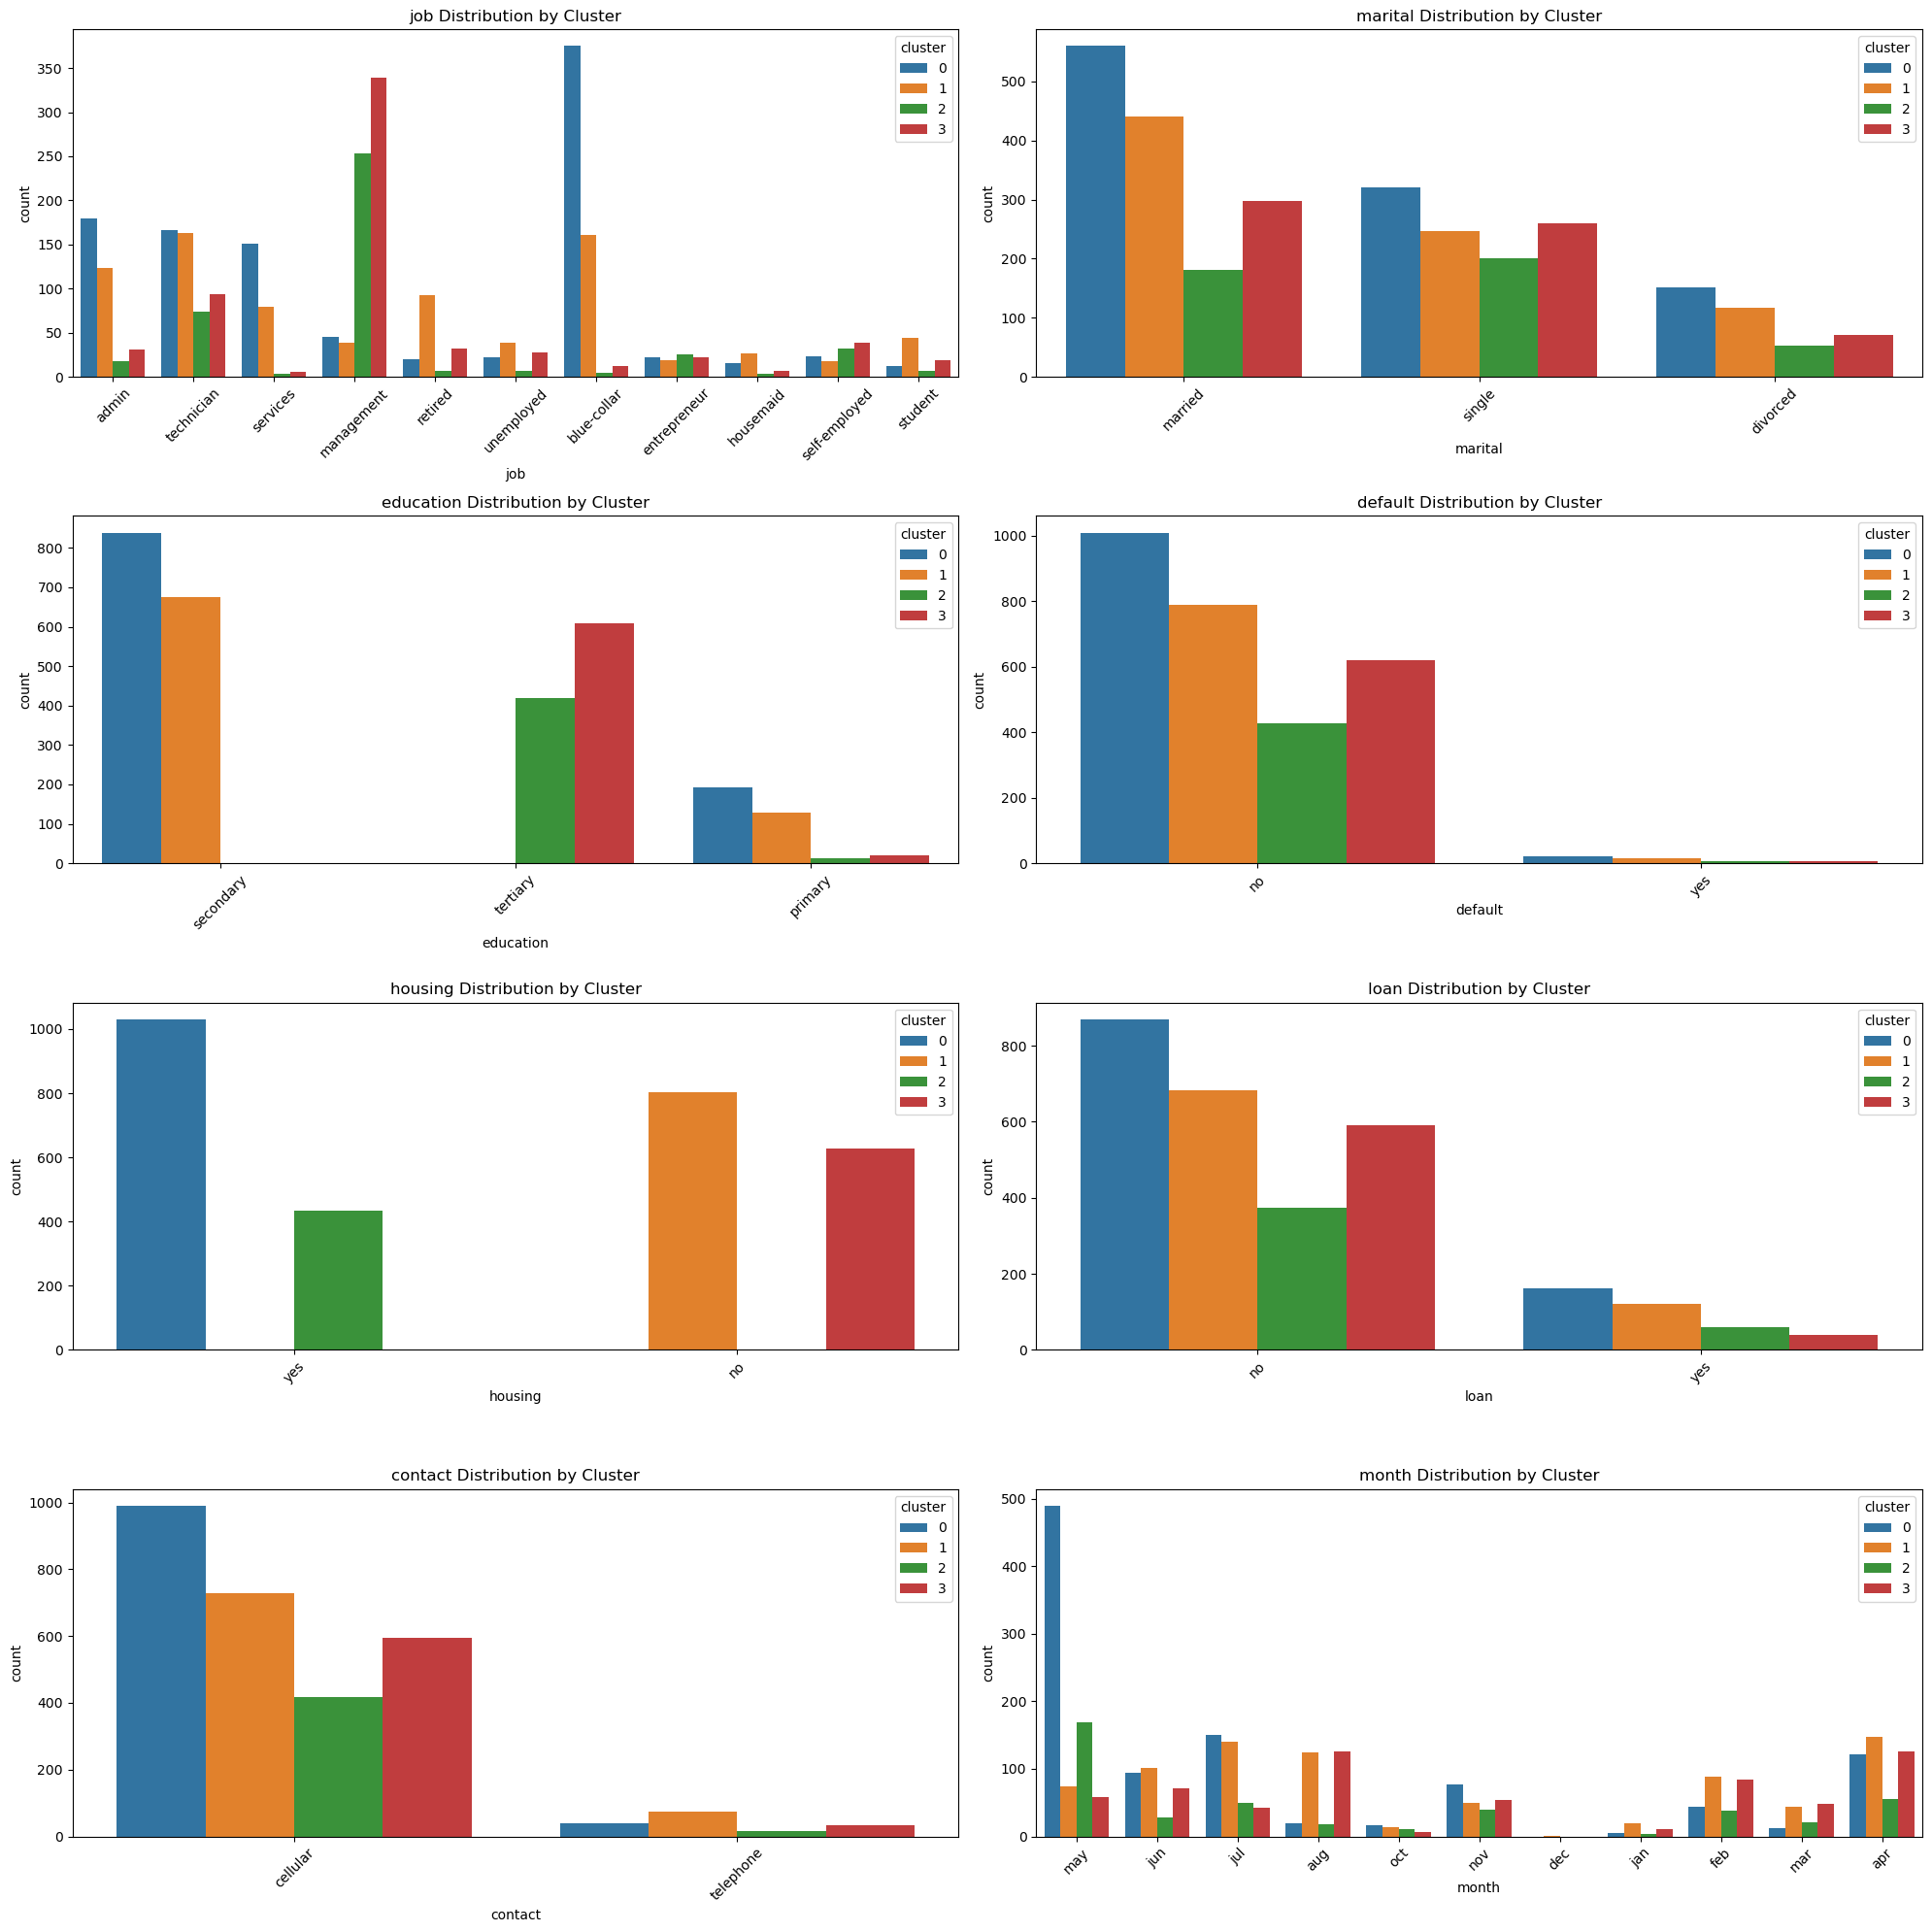

In [136]:
plt.figure(figsize=(20, 20))

for i, col in enumerate(categorical_features, start=1):
    plt.subplot(4, 2, i)
    sns.countplot(data=df_positive, x=col, hue='cluster', palette=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
    plt.title(f'{col} Distribution by Cluster')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Target Priority: Cluster 3 (The High-Value Low-Risk Segment)

Based on the clustering results, **Cluster 3** is the most attractive segment for the investment product.

### Why Prioritize Cluster 3?

- **Highest Financial Capacity**  
  - Highest mean balance
  - Lowest default rate

- **Strong Professional Profile**  
  - Majority of them in management roles  
  - Almost all of them have tertiary education  

- **Debt-Free Status**  
  - No housing loans  
  - Low personal loans  

### Inference

Customers in Cluster 3 likely have:
- The **highest disposable income**
- Strong **financial literacy**
- Greater ability to understand and adopt **investment products**

This makes them the **primary target segment** for marketing and product positioning.

---

## Secondary Priority: Cluster 2 (The Educated Strivers)

Cluster 2 shares strong similarities with Cluster 3 in terms tertiary education, management roles and mean balance, but the key difference is that all of them currently have housing loans.

### Strategic Insight

Although they are carrying debt, Cluster 2 represents a **strong long-term growth segment**.  
As their housing loan obligations decrease over time, they are likely to become high-potential investment customers.

## What Makes Customers Buy? (Key Drivers)

### 1️) Call Duration (The *Engagement* Feature)

**Observation:**  
- The Spearman Correlation Matrix shows that **Duration** has the strongest positive correlation with the target variable.  
- Boxplots for duration show a clear upward shift for successful subscriptions (Y = 1).

**Strategy:**  
This should be the **#1 focus area**.  

If an agent can keep a customer engaged on the phone for a longer period, the probability of a sale increases significantly.

---

### 2️) Balance & "No Loan" Status (The *Ability* Feature)

**Observation:**  
- Successful buyers (Y = 1) tend to have **higher average balances**.  
- They also tend to have **fewer existing loans**.

**Strategy:**  
Use **balance** and **loan status** as qualification filters:

- Prioritize customers with **higher balances**.
- Focus on leads with **no housing loans**.
- Focus on leads with **no personal loans**.

These customers are statistically more likely to convert.

---

### 3️) Contact Timing (The *Opportunity* Feature)

**Observation:**  
- Overall activity is highest in **May**.  
- However, higher relative success rates were observed in **April** and **August** for high-value segments (Cluster 3).

**Strategy:**  
- Prioritize campaigns in **April** and **August**.  
- Focus outreach efforts on high-value segments (Cluster 3) during these months.

---

## Operational Recommendations

| Feature        | Action Plan |
|---------------|------------|
| **Duration**  | Train staff on conversation "hooks" to extend call time past the 3-minute mark. |
| **Job / Education** | Filter leads for **Management roles** and **Tertiary education** first. |
| **Loan Status** | Deprioritize leads with active loans to improve conversion efficiency. |
| **Campaign Frequency** | Limit repeated contacts — conversion rates show diminishing returns after multiple attempts. |

---

## Final Takeaway

Customer purchase behavior is driven by three core factors:

- **Engagement** (Call Duration)  
- **Ability to Invest** (Balance & Debt Status)  
- **Opportunity Timing** (Month of Contact)  

Optimizing these three levers will significantly improve campaign performance and ROI.